# C2: Boundary harmonisation and mechanism-level leakage

This is a follow-up to the frozen C1 200-sample benchmark. C1 is only read, never changed: its masks, manifest, style references and the images from method F are used as input, and everything new is written to a separate `C2_RUN_DIR`. Three things are added that C1 doesn't have. The first is the actual attention-outside-mask leakage, measured with forward hooks on `to_q`, `to_k_ip` and `to_v_ip` (C1's `localisation_gap` is only a CLIP similarity proxy on the output image). The second is the harmonisation methods I (low-strength img2img over the whole composite), J (latent statistics matching towards the surrounding photograph) and K (cross-attention on the unmasked-region tokens), all applied on top of F. The third is the masked-vs-unmasked CLIP gap for I, J and K against F.

The C1 methods (A, A′, B–H, V1–V4 and the reference-off control) are not re-run. The statistics use the same paired approach as C1, with no weighted score and no automatic winner. `C1_RUN_DIR` has to point at a completed C1 run that passed its final verification and has F generated for every sample.

## Environment and C1 run

In [ ]:
import os, sys, gc, re, json, glob, time, hashlib, subprocess, inspect, random, platform
from datetime import datetime, timezone

os.environ['CUBLAS_WORKSPACE_CONFIG'] = ':4096:8'
os.environ['PYTHONHASHSEED'] = '0'

import numpy as np
import torch

SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
torch.use_deterministic_algorithms(True, warn_only=True)

HAS_CUDA = torch.cuda.is_available()
DEVICE = 'cuda' if HAS_CUDA else 'cpu'


def require_gpu(what):
    if not HAS_CUDA:
        raise RuntimeError(f'{what} requires a GPU.')


def sha256_file(path, n=64):
    h = hashlib.sha256()
    with open(path, 'rb') as f:
        for chunk in iter(lambda: f.read(1 << 20), b''):
            h.update(chunk)
    return h.hexdigest()[:n]


def sha256_text(s, n=64):
    return hashlib.sha256(s.encode()).hexdigest()[:n]


print('device:', DEVICE, '|', torch.cuda.get_device_name(0) if HAS_CUDA else 'no CUDA')

device: cuda | NVIDIA A100-SXM4-40GB


In [ ]:
if 'google.colab' in sys.modules:
    from google.colab import drive
    drive.mount('/content/drive')
    from IPython.display import display, Javascript
    display(Javascript('function KA(){document.querySelector('
                       '"colab-toolbar-button#connect")?.click();} setInterval(KA,60000);'))
    print('Drive mounted, keepalive installed')


# completed, verified C1 run
C1_RUN_DIR = '/content/drive/MyDrive/regional_style_transfer/FINAL_RUN_20260827T132200Z'

C1_VERIFICATION_PATH = f'{C1_RUN_DIR}/verification/verification.json'
assert os.path.isdir(C1_RUN_DIR), (
    f'C1_RUN_DIR does not exist: {C1_RUN_DIR}\n'
    f'Set it to the FINAL_RUN_* directory produced by the C1 200-sample benchmark notebook.')
assert os.path.exists(C1_VERIFICATION_PATH), (
    f'{C1_VERIFICATION_PATH} not found. This notebook requires a C1 run whose FINAL EXPERIMENT '
    f'VERIFICATION cell has already completed successfully -- refusing to build on an '
    f'unverified or partial run.')

with open(C1_VERIFICATION_PATH) as f:
    C1_VERIFICATION = json.load(f)
assert C1_VERIFICATION.get('n_failed_critical', 1) == 0, (
    f'C1 run {C1_RUN_DIR} did NOT pass its own final verification '
    f'({C1_VERIFICATION.get("n_failed_critical")} critical failures). Fix and re-freeze C1 '
    f'before running C2 on top of it.')

C1_RUN_ID = C1_VERIFICATION['run_id']
C1_CONFIG_HASH = C1_VERIFICATION['config_hash']
C1_CODE_HASH = C1_VERIFICATION['code_hash']
C1_QWEN_MANIFEST_SHA = C1_VERIFICATION['qwen_manifest_sha256']

print(f'C1 run verified : {C1_RUN_ID}')
print(f'C1 config hash : {C1_CONFIG_HASH}')
print(f'C1 code hash : {C1_CODE_HASH}')
print(f'C1 qwen manifest : {C1_QWEN_MANIFEST_SHA[:16]}')
print(f'C1 critical fails : {C1_VERIFICATION["n_failed_critical"]} (must be 0 -- confirmed)')

Mounted at /content/drive


<IPython.core.display.Javascript object>

Drive mounted, keepalive installed
C1 run verified : FINAL_RUN_20260827T132200Z
C1 config hash : 2f1c4ba89ca6aa07f0269174ad4ef025c1eba59865f1e008f4aff8b80839f4cb
C1 code hash : 18cf058327da4b4c
C1 qwen manifest : b454a1590b65a6b4
C1 critical fails : 0 (must be 0 -- confirmed)


In [ ]:
# C2 writes only to its own run directory, never into C1_RUN_DIR
PROJECT_ROOT = '/content/drive/MyDrive/regional_style_transfer'
RESUME_C2_RUN_ID = None   # existing C2_RUN_* id to resume, None starts fresh

C2_RUN_ID = RESUME_C2_RUN_ID or ('C2_RUN_' + datetime.now(timezone.utc).strftime('%Y%m%dT%H%M%SZ'))
C2_RUN_DIR = f'{PROJECT_ROOT}/{C2_RUN_ID}'
DIRS = {k: f'{C2_RUN_DIR}/{k}' for k in
        ('generated', 'metrics', 'statistics', 'figures', 'checkpoints', 'verification')}
WEIGHTS_DIR = f'{PROJECT_ROOT}/_weights'
for d in list(DIRS.values()):
    os.makedirs(d, exist_ok=True)


def ckpt_path(stage): return f'{DIRS["checkpoints"]}/stage_{stage}.json'

def save_ckpt(stage, obj):
    tmp = ckpt_path(stage) + '.tmp'
    with open(tmp, 'w') as f: json.dump(obj, f, indent=2, default=str)
    os.replace(tmp, ckpt_path(stage))

def load_ckpt(stage):
    p = ckpt_path(stage)
    if not os.path.exists(p): return None
    try:
        with open(p) as f: return json.load(f)
    except Exception:
        return None


MODELS = {}

def release_model(*keys):
    for k in keys:
        obj = MODELS.pop(k, None)
        if obj is not None:
            try:
                if hasattr(obj, 'to'): obj.to('cpu')
            except Exception: pass
            del obj
    gc.collect()
    if HAS_CUDA: torch.cuda.empty_cache(); torch.cuda.synchronize()

print('C2_RUN_ID :', C2_RUN_ID)
print('C2_RUN_DIR:', C2_RUN_DIR)
_existing = [s for s in ('input', 'harm', 'attn', 'stats', 'fig') if load_ckpt(s) is not None]
print('existing checkpoints:', _existing or 'none (fresh C2 run)')

C2_RUN_ID : C2_RUN_20260829T075822Z
C2_RUN_DIR: /content/drive/MyDrive/regional_style_transfer/C2_RUN_20260829T075822Z
existing checkpoints: none (fresh C2 run)


## Frozen C1 inputs

The manifest, masks, style references and the config that produced them are read straight from `C1_RUN_DIR`. The mask and style reference hashes are being checked against C1's own records as they load, and the notebook stops if anything has changed since C1 was frozen.

In [ ]:
import pandas as pd
from PIL import Image
try:
    import pillow_avif
except ImportError:
    pass

manifest_df = pd.read_csv(f'{C1_RUN_DIR}/inputs/manifest.csv')
mask_df = pd.read_csv(f'{C1_RUN_DIR}/masks/mask_validation.csv')
MANIFEST = manifest_df.set_index('sample_id').to_dict('index')
SAMPLE_IDS = sorted(MANIFEST)

MASKS, MASK_META = {}, {}
for sid in SAMPLE_IDS:
    m1p = f'{C1_RUN_DIR}/masks/{sid}_r1.png'
    m2p = f'{C1_RUN_DIR}/masks/{sid}_r2.png'
    row = mask_df[mask_df.sample_id == sid].iloc[0].to_dict()
    assert sha256_file(m1p) == row['mask1_sha256'], f'{sid}: mask1 hash mismatch since C1 froze'
    assert sha256_file(m2p) == row['mask2_sha256'], f'{sid}: mask2 hash mismatch since C1 froze'
    MASKS[sid] = (np.array(Image.open(m1p).convert('L')), np.array(Image.open(m2p).convert('L')))
    MASK_META[sid] = row

CATEGORY_OF_SAMPLE = {sid: MANIFEST[sid]['category'] for sid in SAMPLE_IDS}
NOMINAL_BAND_PX = int(mask_df.nominal_band_px.iloc[0])
print(f'loaded {len(SAMPLE_IDS)} samples, masks re-verified against C1 provenance')

STYLE_ASSETS = f'{PROJECT_ROOT}/_style_refs'
STYLE_HASHES_EXPECTED = C1_VERIFICATION['style_hashes']
STYLE_REFS, STYLE_HASHES = {}, {}
for name, expected in STYLE_HASHES_EXPECTED.items():
    slug = name.replace(' ', '_').lower()
    p = f'{STYLE_ASSETS}/{slug}.png'
    assert os.path.exists(p), f'vendored style reference missing: {p}'
    sha = sha256_file(p)
    assert sha[:16] == expected, (f'{name}: style reference hash has CHANGED since C1 froze '
                                  f'({sha[:16]} vs {expected}). Refusing to proceed.')
    img = Image.open(p).convert('RGB'); img.load()
    STYLE_REFS[name] = img; STYLE_HASHES[name] = sha
print(f'style references re-verified: {list(STYLE_REFS)}')

STYLE_NAME_ALIASES = {'Picasso': 'Delaunay'}
DEGENERATE = set(manifest_df[manifest_df.degenerate_style_pair].sample_id)
print(f'degenerate style pairs (excluded, same as C1): {len(DEGENERATE)}')

loaded 200 samples, masks re-verified against C1 provenance
style references re-verified: ['Van Gogh', 'Cezanne', 'Monet', 'Kandinsky', 'Delaunay']
degenerate style pairs (excluded, same as C1): 0


In [ ]:
import cv2

def _ellipse(px):
    return cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (px * 2 + 1, px * 2 + 1))

def boundary_band(m1, m2, band_px=None, return_px=False):
    '''Identical definition to C1's -- same nominal width, same escalation rule -- so seam/
    band-relative metrics computed here are directly comparable to C1's.'''
    bp = NOMINAL_BAND_PX if band_px is None else band_px
    band = cv2.bitwise_and(cv2.dilate(m1, _ellipse(bp)), cv2.dilate(m2, _ellipse(bp)))
    while band.sum() == 0 and bp < 60:
        bp += 10
        band = cv2.bitwise_and(cv2.dilate(m1, _ellipse(bp)), cv2.dilate(m2, _ellipse(bp)))
    return (band, bp) if return_px else band

def exterior_band(mask, band_px=None, exclude_mask=None):
    bp = NOMINAL_BAND_PX if band_px is None else band_px
    band = cv2.subtract(cv2.dilate(mask, _ellipse(bp)), mask)
    if exclude_mask is not None:
        band = cv2.bitwise_and(band, cv2.bitwise_not(exclude_mask))
    return band


def load_F(sid):
    png = f'{C1_RUN_DIR}/generated/{sid}/F/output.png'
    prov = f'{C1_RUN_DIR}/generated/{sid}/F/provenance.json'
    if not (os.path.exists(png) and os.path.exists(prov)):
        return None, None
    with open(prov) as f:
        rec = json.load(f)

    rec_sample = rec.get('sample_id')
    assert rec_sample == sid, (
        f'{sid}: F provenance sample_id mismatch ({rec_sample!r} vs {sid!r}) -- refusing to '
        f'accept a provenance record for a different sample.')
    rec_method = rec.get('method')
    assert rec_method == 'F', (
        f'{sid}: F provenance method field is {rec_method!r}, expected "F".')

    rec_run_id = rec.get('run_id', rec.get('c1_run_id'))
    assert rec_run_id == C1_RUN_ID, (
        f'{sid}: F provenance run_id ({rec_run_id!r}) does not match the verified C1 run '
        f'({C1_RUN_ID!r}) this notebook is built on. Refusing to accept an output that was '
        f'not produced by that verified run.')

    rec_config_hash = rec.get('config_hash')
    if rec_config_hash is not None:
        assert rec_config_hash == C1_CONFIG_HASH, (
            f'{sid}: F provenance config_hash ({rec_config_hash!r}) does not match '
            f'C1_CONFIG_HASH ({C1_CONFIG_HASH!r}) recorded at C1 verification time.')
    rec_code_hash = rec.get('code_hash')
    if rec_code_hash is not None:
        assert rec_code_hash == C1_CODE_HASH, (
            f'{sid}: F provenance code_hash ({rec_code_hash!r}) does not match '
            f'C1_CODE_HASH ({C1_CODE_HASH!r}) recorded at C1 verification time.')

    rec_out_hash = rec.get('output_sha256') or rec.get('output_hash') or rec.get('image_sha256')
    if rec_out_hash is not None:
        actual_hash = sha256_file(png, n=len(rec_out_hash))
        assert actual_hash == rec_out_hash, (
            f'{sid}: F output.png hash ({actual_hash}) does not match the hash recorded in '
            f'its own provenance.json ({rec_out_hash}) -- the file has changed since C1 froze '
            f'it. Refusing to accept it.')

    img = Image.open(png).convert('RGB'); img.load()
    return img, rec


def content_image(sid):
    p = MANIFEST[sid]['content_path']
    if not os.path.exists(p):
        p = f'{C1_RUN_DIR}/inputs/content_{sid}.png'
    img = Image.open(p).convert('RGB'); img.load()
    return img


CFG_PARENT_METHOD = 'F'
HARM_CSV_ROOT = DIRS['generated']

_avail, _missing = [], []
for sid in SAMPLE_IDS:
    img, rec = load_F(sid)
    (_avail if img is not None else _missing).append(sid)
print(f'method F available for {len(_avail)}/{len(SAMPLE_IDS)} samples')
if _missing:
    print(f'  MISSING F for: {_missing[:10]}{"..." if len(_missing) > 10 else ""}')
    print('  These samples cannot be used as C2 parents and are excluded below.')
C2_SAMPLE_IDS = sorted(set(_avail) - DEGENERATE)
print(f'C2 will run on {len(C2_SAMPLE_IDS)} samples (F available, non-degenerate)')

method F available for 200/200 samples
C2 will run on 200 samples (F available, non-degenerate)


## Attention outside the mask

C1's `localisation_gap` compares the CLIP similarity of the output inside and outside a region, so it is only a proxy measured after generation. Here the IP-Adapter cross-attention is measured during generation instead. Forward hooks on `to_q` and on the IP-Adapter processor's `to_k_ip[0]` / `to_v_ip[0]` are used to rebuild each layer's contribution, and the metric is the contribution magnitude outside the region mask divided by the magnitude over the whole frame (`attention_outside_fraction`), averaged over the instrumented cross-attention layers and denoising steps.

It is measured for F, where style is routed with `ip_adapter_masks`, and for F unmasked, which is the same generation call without `ip_adapter_masks` (global conditioning). C1 never ran F without masks, so the unmasked images are generated here. A one-sample self-test has to pass before the full run. If it fails the section is reported as unavailable and no number is made up.

In [ ]:
def load_diffusion():
    require_gpu('generation')
    if 'pipe' in MODELS: return
    from diffusers import AutoPipelineForInpainting
    from diffusers.image_processor import IPAdapterMaskProcessor
    pipe = AutoPipelineForInpainting.from_pretrained(
        'stable-diffusion-v1-5/stable-diffusion-inpainting',
        torch_dtype=torch.float16, safety_checker=None, cache_dir=WEIGHTS_DIR).to(DEVICE)
    pipe.load_ip_adapter('h94/IP-Adapter', subfolder='models',
                         weight_name=['ip-adapter_sd15.bin'])
    pipe.set_progress_bar_config(disable=True)
    procs = {n: type(p).__name__ for n, p in pipe.unet.attn_processors.items()
             if n.endswith('attn2.processor')}
    assert procs and all(t == 'IPAdapterAttnProcessor2_0' for t in procs.values())
    assert pipe.unet.config.in_channels == 9
    MODELS['pipe'] = pipe
    MODELS['mask_proc'] = IPAdapterMaskProcessor()
    MODELS['n_attn2'] = len(procs)
    print(f'{len(procs)} cross-attention processors verified')


def _gen(seed=None):
    return torch.Generator(device=DEVICE).manual_seed(42 if seed is None else seed)

def make_ip_masks(masks, h, w):
    t = MODELS['mask_proc'].preprocess([Image.fromarray(m).convert('L') for m in masks],
                                       height=h, width=w)
    return [t.reshape(1, t.shape[0], t.shape[2], t.shape[3])]

def _query_grid_shape(num_queries, ref_h, ref_w):
    ratio = ref_w / ref_h
    gh = max(int(round((num_queries / ratio) ** 0.5)), 1)
    gw = max(int(round(num_queries / gh)), 1) if gh else num_queries
    if gh * gw != num_queries:
        for cand_h in range(max(gh - 3, 1), gh + 4):
            if cand_h > 0 and num_queries % cand_h == 0:
                gh, gw = cand_h, num_queries // cand_h
                break
    return gh, gw

The hooks append the `to_k_ip[0]` / `to_v_ip[0]` outputs instead of overwriting them. Only one IP-Adapter is loaded, so its k/v layers are called once per region image inside a single forward pass, and an assignment would only keep the second region. The reconstruction then multiplies each region's contribution by its own downsampled mask before summing the regions, which is what `IPAdapterAttnProcessor2_0` does. Without this step dense attention lands outside any region anyway, and that is what gave the 0.2843 in an earlier self-test.

The metric is an approximate reconstruction of the masked, per-region contribution, built from the hooked linear layer outputs and a recomputed scaled-dot-product attention. It is not the literal internal tensor of the installed processor.

In [ ]:
import torch.nn.functional as Fnn

ATTN = {'q': {}, 'k': {}, 'v': {}, 'active': False, 'records': [], 'handles': [], 'step': 0,
       'region_masks': None}

def _attn_layers():
    return [(n, m) for n, m in MODELS['pipe'].unet.named_modules()
            if n.endswith('attn2') and hasattr(m, 'processor') and hasattr(m.processor, 'to_k_ip')]

def _set_region_masks(masks_hw, content_h, content_w):
    if masks_hw is None:
        ATTN['region_masks'] = None
        return
    ATTN['region_masks'] = [torch.from_numpy((m > 127).astype(np.float32)) for m in masks_hw]
    ATTN['content_hw'] = (content_h, content_w)

def _install_hooks():
    _remove_hooks()
    for name, mod in _attn_layers():
        def mk(n, kind):
            def hook(_m, _i, o):
                if ATTN['active']:
                    # one call per region image, so append instead of overwriting
                    ATTN[kind].setdefault(n, []).append(o.detach())
            return hook
        ATTN['handles'].append(mod.to_q.register_forward_hook(mk(name, 'q')))
        ATTN['handles'].append(mod.processor.to_k_ip[0].register_forward_hook(mk(name, 'k')))
        ATTN['handles'].append(mod.processor.to_v_ip[0].register_forward_hook(mk(name, 'v')))

        def mk_out(n, module):
            def hook(_m, _i, _o):
                if not ATTN['active']: return
                qs, ks, vs = ATTN['q'].get(n), ATTN['k'].get(n), ATTN['v'].get(n)
                if not qs or not ks or not vs: return
                try:
                    q = qs[-1]
                    heads = module.heads
                    b, sq, dim = q.shape
                    hd = dim // heads
                    qh = q.reshape(b, sq, heads, hd).transpose(1, 2)

                    region_masks = ATTN.get('region_masks')
                    total_ctx = None
                    n_regions = len(ks)
                    for ri in range(n_regions):
                        k, v = ks[ri], vs[ri]
                        # the unmasked path can keep an extra num_images=1 dim
                        if k.ndim == 4: k = k.reshape(k.shape[0], -1, k.shape[-1])
                        if v.ndim == 4: v = v.reshape(v.shape[0], -1, v.shape[-1])
                        kh = k.reshape(k.shape[0], k.shape[1], heads, hd).transpose(1, 2)
                        vh = v.reshape(v.shape[0], v.shape[1], heads, hd).transpose(1, 2)
                        if kh.shape[0] != qh.shape[0]:
                            kh = kh.expand(qh.shape[0], -1, -1, -1)
                            vh = vh.expand(qh.shape[0], -1, -1, -1)
                        probs = torch.softmax((qh.float() @ kh.float().transpose(-1, -2)) /
                                              (hd ** 0.5), dim=-1)
                        ctx = (probs @ vh.float()).transpose(1, 2).reshape(b, sq, dim)
                        if region_masks is not None and ri < len(region_masks):
                            # scale this region's contribution by its own downsampled mask, like the real processor
                            ch, cw = ATTN['content_hw']
                            gh, gw = _query_grid_shape(sq, ch, cw)
                            if gh * gw == sq:
                                m_ds = Fnn.interpolate(region_masks[ri][None, None], size=(gh, gw),
                                                       mode='area').reshape(1, sq, 1)
                                ctx = ctx * m_ds.to(ctx.device, ctx.dtype)
                        total_ctx = ctx if total_ctx is None else total_ctx + ctx
                    mag = total_ctx.norm(dim=-1)
                    ATTN['records'].append({'layer': n, 'step': ATTN['step'],
                                            'mag': mag[-1].detach().cpu()})
                except Exception as e:
                    ATTN.setdefault('errors', []).append(f'{n}: {type(e).__name__}: {e}')
            return hook
        ATTN['handles'].append(mod.register_forward_hook(mk_out(name, mod)))

def _remove_hooks():
    for h in ATTN['handles']:
        try: h.remove()
        except Exception: pass
    ATTN['handles'] = []

def _capture_reset(step=0):
    ATTN['records'] = []; ATTN['q'] = {}; ATTN['k'] = {}; ATTN['v'] = {}
    ATTN['step'] = step

def _reset_errors():
    ATTN['errors'] = []

def _outside_fraction(records, m_union):
    fracs = []
    for rec in records:
        mag = rec['mag'].float(); n = mag.numel()
        H, W = ATTN.get('content_hw', m_union.shape)
        gh, gw = _query_grid_shape(n, H, W)
        if gh * gw != n: continue
        grid = mag.reshape(1, 1, gh, gw)
        inside_ref = torch.from_numpy((m_union > 127).astype(np.float32))
        mask = Fnn.interpolate(inside_ref[None, None], size=(gh, gw), mode='area')[0, 0]
        total = float(grid.sum())
        if total <= 0: continue
        fracs.append(float((grid[0, 0] * (1.0 - mask)).sum()) / total)
    return fracs


@torch.no_grad()
def measure_attention(content, mask_for_metric, m1, m2, s1, s2, p1, p2, masked, seed=None,
                      capture_every=5, steps=30, guidance=7.5, strength=0.75, ip_scale=0.70):
    pipe = MODELS['pipe']
    _install_hooks()
    all_fracs, per_layer = [], {}
    try:
        ATTN['active'] = True
        def _cb(_p, step, _t, kw):
            if step % capture_every == 0:
                fr = _outside_fraction(ATTN['records'], mask_for_metric)
                for rec, f in zip(ATTN['records'], fr):
                    per_layer.setdefault(rec['layer'], []).append(f)
                all_fracs.extend(fr)
            _capture_reset(step + 1)
            return kw
        _reset_errors()
        _capture_reset(0)

        if masked:
            pipe.set_ip_adapter_scale([[ip_scale, ip_scale]])
            ip_image = [[s1, s2]]
            _set_region_masks([m1, m2], content.height, content.width)
        else:
            # scalar scale: diffusers' no-mask path can't take a list (both entries are equal anyway)
            pipe.set_ip_adapter_scale([ip_scale])
            ip_image = [[s1, s2]]
            _set_region_masks(None, content.height, content.width)

        kwargs = dict(prompt=f'{p1}, {p2}', image=content,
                     mask_image=Image.fromarray(mask_for_metric).convert('L'),
                     ip_adapter_image=ip_image,
                     negative_prompt='ugly, blurry, distorted, watermark, hard seam',
                     num_inference_steps=steps, guidance_scale=guidance, strength=strength,
                     generator=_gen(seed), callback_on_step_end=_cb)
        if masked:
            kwargs['cross_attention_kwargs'] = {'ip_adapter_masks': make_ip_masks(
                [m1, m2], content.height, content.width)}
        out = pipe(**kwargs).images[0]
    finally:
        ATTN['active'] = False
        _remove_hooks()
        pipe.set_ip_adapter_scale([[0.70, 0.70]])
    return out, {'outside_fraction': float(np.mean(all_fracs)) if all_fracs else float('nan'),
                'n_captures': len(all_fracs),
                'per_layer': {k: float(np.mean(v)) for k, v in per_layer.items()},
                'errors': len(ATTN.get('errors', []))}


ATTN_CODE_HASH = sha256_text(inspect.getsource(_install_hooks) + inspect.getsource(_outside_fraction)
                             + inspect.getsource(measure_attention), 16)

The self-test checks two things on one sample. The first is that the instrumentation works: no hook errors, finite values, captures present, and a record from every one of the `n_attn2` cross-attention layers. The second is that masked routing gives a lower outside-fraction than unmasked on the same sample and seed, which doesn't depend on picking a cutoff. `ATTN_AVAILABLE` is only set to `True` if both pass.

In [ ]:
ATTN_AVAILABLE, ATTN_STATUS = False, 'not attempted'
try:
    require_gpu('attention self-test')
    load_diffusion()
    _sid = C2_SAMPLE_IDS[0]
    _m1, _m2 = MASKS[_sid]
    _row = MANIFEST[_sid]
    _content = content_image(_sid)
    _s1, _s2 = STYLE_REFS[_row['style1_name']], STYLE_REFS[_row['style2_name']]
    _union = np.maximum(_m1, _m2)
    _p1, _p2 = _row.get('prompt1', _row['instruction']), _row.get('prompt2', '')

    _, _meta_masked = measure_attention(_content, _union, _m1, _m2, _s1, _s2, _p1, _p2,
                                        masked=True)
    _, _meta_unmasked = measure_attention(_content, _union, _m1, _m2, _s1, _s2, _p1, _p2,
                                          masked=False)

    assert _meta_masked['n_captures'] > 0 and _meta_unmasked['n_captures'] > 0, \
        'no attention captured in one or both conditions'
    assert np.isfinite(_meta_masked['outside_fraction']) and np.isfinite(_meta_unmasked['outside_fraction']), \
        'outside fraction not finite in one or both conditions'
    assert _meta_masked['errors'] == 0 and _meta_unmasked['errors'] == 0, \
        f"hook errors: masked={_meta_masked['errors']}, unmasked={_meta_unmasked['errors']}"
    _n_layers_hit = len(_meta_masked['per_layer'])
    assert _n_layers_hit == MODELS['n_attn2'], (
        f"only {_n_layers_hit}/{MODELS['n_attn2']} instrumented cross-attention layers "
        f"produced a record -- some layer's hooks are not firing")

    _routing_effective = _meta_masked['outside_fraction'] < _meta_unmasked['outside_fraction']

    print(f"self-test: masked outside-fraction   = {_meta_masked['outside_fraction']:.4f} "
          f"({_meta_masked['n_captures']} captures / {_n_layers_hit} layers, "
          f"{_meta_masked['errors']} hook errors)")
    print(f"self-test: unmasked outside-fraction = {_meta_unmasked['outside_fraction']:.4f} "
          f"({_meta_unmasked['n_captures']} captures, {_meta_unmasked['errors']} hook errors)")
    print(f"masked < unmasked (routing has a measurable effect): {_routing_effective}")

    assert _routing_effective, (
        'masked routing does NOT reduce attention-outside-mask relative to unmasked, global '
        'conditioning on this sample. Either the reconstruction is still not faithfully '
        'representing what ip_adapter_masks does, or masked routing genuinely is not '
        'constraining attention here -- either way this does not pass the honesty gate.')

    ATTN_AVAILABLE = True
    ATTN_STATUS = (f"structural checks passed ({_n_layers_hit}/{MODELS['n_attn2']} layers, "
                   f"0 hook errors); masked ({_meta_masked['outside_fraction']:.4f}) < "
                   f"unmasked ({_meta_unmasked['outside_fraction']:.4f}) confirmed on probe sample")
except Exception as e:
    ATTN_STATUS = f'{type(e).__name__}: {e}'

print('\nATTENTION INSTRUMENTATION AVAILABLE:', ATTN_AVAILABLE)
print('status:', ATTN_STATUS)
if not ATTN_AVAILABLE:
    print('This section will be marked UNAVAILABLE / LIMITATION in the final report. '
         'No attention numbers will be fabricated.')

[transformers] `Siglip2ImageProcessorFast` is deprecated. The `Fast` suffix for image processors has been removed; use `Siglip2ImageProcessor` instead.
/usr/local/lib/python3.13/dist-packages/huggingface_hub/utils/_validators.py:205: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/huggingface_hub/utils/_auth.py:138: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
  warnings.warn(f"\nError while fetching `HF_TOKEN` secret value from your vault: '{str(e)}'.")
/usr/local/lib/python3.13/dist-packages/diffusers/utils/deprecation_utils.py:23: FutureWarning: `torch_dtype` is deprecated and will be removed in version 1.0.0. Please use `dtype` instead.
  deprecate("torch_dtype", "1.0.0", _TORCH_DTYP

Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

An error occurred while trying to fetch /content/drive/MyDrive/regional_style_transfer/_weights/models--stable-diffusion-v1-5--stable-diffusion-inpainting/snapshots/8a4288a76071f7280aedbdb3253bdb9e9d5d84bb/unet: Error no file named diffusion_pytorch_model.safetensors found in directory /content/drive/MyDrive/regional_style_transfer/_weights/models--stable-diffusion-v1-5--stable-diffusion-inpainting/snapshots/8a4288a76071f7280aedbdb3253bdb9e9d5d84bb/unet.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.
An error occurred while trying to fetch /content/drive/MyDrive/regional_style_transfer/_weights/models--stable-diffusion-v1-5--stable-diffusion-inpainting/snapshots/8a4288a76071f7280aedbdb3253bdb9e9d5d84bb/vae: Error no file named diffusion_pytorch_model.safetensors found in directory /content/drive/MyDrive/regional_style_transfer/_weights/models--stable-diffusion-v1-5--stable-diffusion-inpainting/snapshots/8a4288a76071f7280aedbdb3253bdb9e9d5d84bb/

models/ip-adapter_sd15.bin: reconstructing file:   0%|          |  0.00B / 44.6MB            

...

models/image_encoder/model.safetensors: reconstructing file:   0%|          |  0.00B / 2.53GB            

models/image_encoder/model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/520 [00:00<?, ?it/s]

There are modules in UNet2DConditionModel that should be kept in float32: []. Casting directly with `to()` can lead to inconsistent results; set `torch_dtype` in `from_pretrained()` instead to keep these modules in float32.


16 cross-attention processors verified
self-test: masked outside-fraction   = 0.0268 (80 captures / 16 layers, 0 hook errors)
self-test: unmasked outside-fraction = 0.2821 (80 captures, 0 hook errors)
masked < unmasked (routing has a measurable effect): True

ATTENTION INSTRUMENTATION AVAILABLE: True
status: structural checks passed (16/16 layers, 0 hook errors); masked (0.0268) < unmasked (0.2821) confirmed on probe sample


`ATTN_CODE_HASH` is stored in the attention checkpoint. If the hook code has changed since the checkpoint was written it is discarded and the stage starts again, so old and new measurements never end up in the same CSV.

In [ ]:
_ckptA = load_ckpt('attn') or {'done': [], 'rows': [], 'code_hash': None}
if _ckptA.get('code_hash') != ATTN_CODE_HASH:
    if _ckptA.get('rows'):
        print(f"attn checkpoint was written under a different attention-hook code hash "
             f"({_ckptA.get('code_hash')} vs {ATTN_CODE_HASH}) -- discarding "
             f"{len(_ckptA['rows'])} old row(s), this stage will regenerate all measurements.")
    _ckptA = {'done': [], 'rows': [], 'code_hash': ATTN_CODE_HASH}
attn_rows = _ckptA['rows']
done_attn = {tuple(x) for x in _ckptA['done']}

if ATTN_AVAILABLE:
    _todo = [(sid, cond) for sid in C2_SAMPLE_IDS for cond in ('masked', 'unmasked')
             if (sid, cond) not in done_attn]
    print(f'{len(_todo)} (sample, condition) pairs remaining')
    _t0 = time.time()
    # a pair is only marked done after a successful measurement, so failures are retried on resume
    _attn_failures = []
    for i, (sid, cond) in enumerate(_todo, 1):
        row = MANIFEST[sid]; m1, m2 = MASKS[sid]
        content = content_image(sid)
        s1, s2 = STYLE_REFS[row['style1_name']], STYLE_REFS[row['style2_name']]
        union = np.maximum(m1, m2)
        try:
            _, meta = measure_attention(content, union, m1, m2, s1, s2,
                                        row.get('prompt1', row['instruction']),
                                        row.get('prompt2', ''), masked=(cond == 'masked'))
            attn_rows.append({'sample_id': sid, 'condition': cond,
                              'category': CATEGORY_OF_SAMPLE[sid],
                              'attention_outside_fraction': meta['outside_fraction'],
                              'n_captures': meta['n_captures'], 'hook_errors': meta['errors']})
        except Exception as e:
            attn_rows[:] = [r for r in attn_rows
                            if not (r['sample_id'] == sid and r['condition'] == cond)]
            attn_rows.append({'sample_id': sid, 'condition': cond,
                              'category': CATEGORY_OF_SAMPLE[sid],
                              'attention_outside_fraction': float('nan'),
                              'n_captures': 0, 'hook_errors': -1, 'error': str(e)})
            _attn_failures.append({'sample_id': sid, 'condition': cond,
                                   'error': f'{type(e).__name__}: {e}'})
            print(f'  {sid}/{cond} FAILED (left incomplete, will retry on resume): '
                 f'{type(e).__name__}: {e}')
        else:
            done_attn.add((sid, cond))
        if i % 20 == 0 or i == len(_todo):
            save_ckpt('attn', {'done': [list(x) for x in done_attn], 'rows': attn_rows,
                               'code_hash': ATTN_CODE_HASH})
            print(f'  {i}/{len(_todo)} | {time.time()-_t0:.0f}s | checkpoint saved')
    save_ckpt('attn', {'done': [list(x) for x in done_attn], 'rows': attn_rows,
                       'code_hash': ATTN_CODE_HASH})
    attn_df = pd.DataFrame(attn_rows)
    attn_df.to_csv(f'{DIRS["metrics"]}/attention_outside_mask.csv', index=False)
    _n_failed = int((attn_df.hook_errors == -1).sum()) if len(attn_df) else 0
    print(f'\n{len(attn_df)} attention measurements ({_n_failed} failed and excluded, see error column)')
    if _attn_failures:
        print(f'{len(_attn_failures)} pair(s) FAILED this pass and remain incomplete '
             f'(not in done_attn, will retry on resume): '
             f'{[(f["sample_id"], f["condition"]) for f in _attn_failures][:10]}')
    print(attn_df.groupby('condition').attention_outside_fraction
          .agg(['mean', 'std', 'count']).round(4).to_string())
    release_model('pipe', 'mask_proc')
else:
    attn_df = pd.DataFrame()
    print('SKIPPED: attention instrumentation unavailable. See ATTN_STATUS above.')


400 (sample, condition) pairs remaining
  20/400 | 66s | checkpoint saved
  40/400 | 131s | checkpoint saved
  60/400 | 197s | checkpoint saved
  80/400 | 262s | checkpoint saved
  100/400 | 327s | checkpoint saved
  120/400 | 393s | checkpoint saved
  140/400 | 459s | checkpoint saved
  160/400 | 525s | checkpoint saved
  180/400 | 591s | checkpoint saved
  200/400 | 657s | checkpoint saved
  220/400 | 722s | checkpoint saved
  240/400 | 787s | checkpoint saved
  260/400 | 851s | checkpoint saved
  280/400 | 916s | checkpoint saved
  300/400 | 980s | checkpoint saved
  320/400 | 1045s | checkpoint saved
  340/400 | 1110s | checkpoint saved
  360/400 | 1176s | checkpoint saved
  380/400 | 1241s | checkpoint saved
  400/400 | 1305s | checkpoint saved

400 attention measurements (0 failed and excluded, see error column)
             mean     std  count
condition                       
masked     0.0231  0.0178    200
unmasked   0.2015  0.1686    200


Pipelines loaded with `dtype=torch.float16` cannot run with `cpu` device. It is not recommended to move them to `cpu` as running them will fail. Please make sure to use an accelerator to run the pipeline in inference, due to the lack of support for`float16` operations on this device in PyTorch. Please, remove the `dtype=torch.float16` argument, or use another device for inference.
Pipelines loaded with `dtype=torch.float16` cannot run with `cpu` device. It is not recommended to move them to `cpu` as running them will fail. Please make sure to use an accelerator to run the pipeline in inference, due to the lack of support for`float16` operations on this device in PyTorch. Please, remove the `dtype=torch.float16` argument, or use another device for inference.
Pipelines loaded with `dtype=torch.float16` cannot run with `cpu` device. It is not recommended to move them to `cpu` as running them will fail. Please make sure to use an accelerator to run the pipeline in inference, due to the lac

## Harmonisation methods (I, J, K)

All three are applied on top of F and aim at consistency with the original photograph (palette and lighting), unlike C1's E and H, which push the seam towards more style. I is a low-strength img2img pass over the whole composite on the same 9-channel inpainting UNet, with no style injected (`ip_scale=0`). J matches the latent mean and std of the generated region to those of the unmasked surround. K adds a third IP-Adapter branch carrying the unmasked surround, routed with `ip_adapter_masks` to the seam band only. K uses the same verified `IPAdapterAttnProcessor2_0` path as F. None of them is assumed to be better, that is left to the statistics.

In [ ]:
load_diffusion()

@torch.no_grad()
def _to_latent(pil):
    pipe = MODELS['pipe']
    px = pipe.image_processor.preprocess(pil).to(pipe.device, pipe.unet.dtype)
    return pipe.vae.encode(px).latent_dist.mode() * pipe.vae.config.scaling_factor

@torch.no_grad()
def _from_latent(lat):
    pipe = MODELS['pipe']
    dec = pipe.vae.decode(lat / pipe.vae.config.scaling_factor).sample
    return pipe.image_processor.postprocess(dec, output_type='pil')[0]

HARM_CONFIG = {'harmonise_strength': 0.20, 'harmonise_guidance': 7.5, 'harmonise_steps': 30,
               'latent_match_alpha': 0.50, 'latent_mask_blur': 2,
               'context_scale': 0.35, 'context_band_px': 30, 'context_min_surround_frac': 0.05}


@torch.no_grad()
def method_I(parent, content, m1, m2, p1, p2, seed=None):
    pipe = MODELS['pipe']; device, dtype = pipe.device, pipe.unet.dtype
    try:
        pipe.set_ip_adapter_scale(0.0)
        px = pipe.image_processor.preprocess(parent).to(device, dtype)
        lat0 = pipe.vae.encode(px).latent_dist.mode() * pipe.vae.config.scaling_factor
        h, w = lat0.shape[-2:]
        mask_lat = torch.zeros(1, 1, h, w, device=device, dtype=dtype)
        masked_lat = lat0.clone()
        pe, npe = pipe.encode_prompt(f'{p1}, {p2}', device, 1, True,
                                     negative_prompt='ugly, blurry, distorted, watermark, hard seam')
        emb = torch.cat([npe, pe])
        added = {'image_embeds': pipe.prepare_ip_adapter_image_embeds(
            ip_adapter_image=parent, ip_adapter_image_embeds=None, device=device,
            num_images_per_prompt=1, do_classifier_free_guidance=True)}
        steps = HARM_CONFIG['harmonise_steps']
        pipe.scheduler.set_timesteps(steps, device=device)
        t0 = max(steps - int(round(steps * HARM_CONFIG['harmonise_strength'])), 0)
        ts = pipe.scheduler.timesteps[t0:]
        from diffusers.utils.torch_utils import randn_tensor
        noise = randn_tensor(lat0.shape, generator=_gen(seed), device=device, dtype=dtype)
        latents = pipe.scheduler.add_noise(lat0, noise, ts[:1])
        for t in ts:
            inp = pipe.scheduler.scale_model_input(torch.cat([latents] * 2), t)
            inp = torch.cat([inp, mask_lat.repeat(2, 1, 1, 1), masked_lat.repeat(2, 1, 1, 1)], 1)
            pred = pipe.unet(inp, t, encoder_hidden_states=emb, added_cond_kwargs=added).sample
            pu, pc = pred.chunk(2)
            latents = pipe.scheduler.step(pu + HARM_CONFIG['harmonise_guidance'] * (pc - pu),
                                          t, latents).prev_sample
        return _from_latent(latents)
    finally:
        pipe.set_ip_adapter_scale([[0.70, 0.70]])


def _latent_mask(mask_u8, h, w, blur_px=0):
    t = torch.from_numpy((mask_u8 > 127).astype(np.float32))[None, None]
    t = Fnn.interpolate(t, size=(h, w), mode='area')
    if blur_px:
        k = int(blur_px) * 2 + 1
        g = torch.arange(k, dtype=torch.float32) - k // 2
        g = torch.exp(-(g ** 2) / (2 * (blur_px / 2.0) ** 2)); g = g / g.sum()
        t = Fnn.conv2d(Fnn.pad(t, (k // 2, k // 2, 0, 0), mode='replicate'), g.view(1, 1, 1, k))
        t = Fnn.conv2d(Fnn.pad(t, (0, 0, k // 2, k // 2), mode='replicate'), g.view(1, 1, k, 1))
    return t.clamp(0, 1)


@torch.no_grad()
def method_J(parent, content, m1, m2, p1, p2, seed=None):
    alpha = HARM_CONFIG['latent_match_alpha']
    lat_out, lat_src = _to_latent(parent), _to_latent(content)
    h, w = lat_out.shape[-2:]
    union = np.maximum(m1, m2)
    soft = _latent_mask(union, h, w, HARM_CONFIG['latent_mask_blur']).to(lat_out.device, lat_out.dtype)
    hard = _latent_mask(union, h, w, 0).to(lat_out.device, lat_out.dtype)
    surround = 1.0 - hard
    if surround.sum() < 8 or hard.sum() < 8: return parent
    def st(lat, wgt):
        s = wgt.sum()
        mu = (lat * wgt).sum(dim=(2, 3), keepdim=True) / s
        var = ((lat - mu) ** 2 * wgt).sum(dim=(2, 3), keepdim=True) / s
        return mu, var.clamp_min(1e-8).sqrt()
    mu_g, sd_g = st(lat_out, hard); mu_r, sd_r = st(lat_src, surround)
    matched = (lat_out - mu_g) / sd_g * sd_r + mu_r
    matched = alpha * matched + (1 - alpha) * lat_out
    return _from_latent(lat_out * (1 - soft) + matched * soft)


def _context_image(content, m1, m2):
    union = np.maximum(m1, m2) > 127
    if (~union).mean() < HARM_CONFIG['context_min_surround_frac']:
        return content, 'full_photo'
    ys, xs = np.where(~union)
    a = np.asarray(content.convert('RGB'))
    crop = Image.fromarray(a).crop((int(xs.min()), int(ys.min()), int(xs.max()) + 1, int(ys.max()) + 1))
    return crop, 'surround_crop'


def method_K(content, m1, m2, s1, s2, p1, p2, seed=None):
    pipe = MODELS['pipe']
    ctx_img, ctx_mode = _context_image(content, m1, m2)
    band = boundary_band(m1, m2, HARM_CONFIG['context_band_px'])
    sc, ctx = 0.70, HARM_CONFIG['context_scale']
    try:
        pipe.set_ip_adapter_scale([[sc, sc, ctx]])
        masks = make_ip_masks([m1, m2, band], content.height, content.width)
        with torch.inference_mode():
            out = pipe(prompt=f'{p1}, {p2}', image=content,
                       mask_image=Image.fromarray(np.maximum(m1, m2)).convert('L'),
                       ip_adapter_image=[[s1, s2, ctx_img]],
                       negative_prompt='ugly, blurry, distorted, watermark, hard seam',
                       num_inference_steps=30, guidance_scale=7.5, strength=0.75,
                       cross_attention_kwargs={'ip_adapter_masks': masks},
                       generator=_gen(seed)).images[0]
    finally:
        pipe.set_ip_adapter_scale([[0.70, 0.70]])
    return out, ctx_mode


HARM_CONFIG_HASH = sha256_text(json.dumps(HARM_CONFIG, sort_keys=True), 16)
HARM_CODE_HASH = sha256_text(
    inspect.getsource(method_I) + inspect.getsource(method_J) + inspect.getsource(method_K) +
    inspect.getsource(_to_latent) + inspect.getsource(_from_latent) +
    inspect.getsource(_latent_mask) + inspect.getsource(_context_image), 16)
print(f'HARM_CONFIG_HASH: {HARM_CONFIG_HASH}')
print(f'HARM_CODE_HASH  : {HARM_CODE_HASH}')

/usr/local/lib/python3.13/dist-packages/huggingface_hub/utils/_validators.py:205: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/diffusers/utils/deprecation_utils.py:23: FutureWarning: `torch_dtype` is deprecated and will be removed in version 1.0.0. Please use `dtype` instead.
  deprecate("torch_dtype", "1.0.0", _TORCH_DTYPE_DEPRECATION_MESSAGE)


Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

An error occurred while trying to fetch /content/drive/MyDrive/regional_style_transfer/_weights/models--stable-diffusion-v1-5--stable-diffusion-inpainting/snapshots/8a4288a76071f7280aedbdb3253bdb9e9d5d84bb/unet: Error no file named diffusion_pytorch_model.safetensors found in directory /content/drive/MyDrive/regional_style_transfer/_weights/models--stable-diffusion-v1-5--stable-diffusion-inpainting/snapshots/8a4288a76071f7280aedbdb3253bdb9e9d5d84bb/unet.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.
An error occurred while trying to fetch /content/drive/MyDrive/regional_style_transfer/_weights/models--stable-diffusion-v1-5--stable-diffusion-inpainting/snapshots/8a4288a76071f7280aedbdb3253bdb9e9d5d84bb/vae: Error no file named diffusion_pytorch_model.safetensors found in directory /content/drive/MyDrive/regional_style_transfer/_weights/models--stable-diffusion-v1-5--stable-diffusion-inpainting/snapshots/8a4288a76071f7280aedbdb3253bdb9e9d5d84bb/

Loading weights:   0%|          | 0/520 [00:00<?, ?it/s]

There are modules in UNet2DConditionModel that should be kept in float32: []. Casting directly with `to()` can lead to inconsistent results; set `torch_dtype` in `from_pretrained()` instead to keep these modules in float32.


16 cross-attention processors verified
HARM_CONFIG_HASH: ec07e95cef196de1
HARM_CODE_HASH  : 45a8872ac103ff4d


Generation is checkpointed and can resume at (sample, method) level.

In [ ]:
def out_paths(sid, method):
    d = f'{DIRS["generated"]}/{sid}/{method}'
    return f'{d}/output.png', f'{d}/provenance.json'

def save_harm_output(sid, method, img, extra=None):
    png, prov = out_paths(sid, method)
    os.makedirs(os.path.dirname(png), exist_ok=True)
    img.save(png, 'PNG')
    rec = {'sample_id': sid, 'method': method, 'parent': 'F', 'c1_run_id': C1_RUN_ID,
          'c2_run_id': C2_RUN_ID, 'saved_at': datetime.now(timezone.utc).isoformat(),
          'harm_config_hash': HARM_CONFIG_HASH, 'harm_code_hash': HARM_CODE_HASH,
          **(extra or {})}
    with open(prov, 'w') as f: json.dump(rec, f, indent=2)

def load_harm_cached(sid, method):
    png, prov = out_paths(sid, method)
    if not (os.path.exists(png) and os.path.exists(prov)): return None, None
    with open(prov) as f: rec = json.load(f)
    if (rec.get('sample_id') != sid or
        rec.get('method') != method or
        rec.get('parent') != 'F' or
        rec.get('c1_run_id') != C1_RUN_ID or
        rec.get('harm_config_hash') != HARM_CONFIG_HASH or
        rec.get('harm_code_hash') != HARM_CODE_HASH):
        return None, None
    img = Image.open(png).convert('RGB'); img.load()
    return img, rec


_ckptH = load_ckpt('harm') or {'done': [], 'context_modes': {},
                               'harm_config_hash': HARM_CONFIG_HASH,
                               'harm_code_hash': HARM_CODE_HASH}
if (_ckptH.get('harm_config_hash') != HARM_CONFIG_HASH or
    _ckptH.get('harm_code_hash') != HARM_CODE_HASH):
    if _ckptH.get('done'):
        print(f"harm checkpoint was written under different I/J/K config/code hashes "
             f"(config {_ckptH.get('harm_config_hash')} vs {HARM_CONFIG_HASH}, "
             f"code {_ckptH.get('harm_code_hash')} vs {HARM_CODE_HASH}) -- discarding "
             f"{len(_ckptH['done'])} 'done' marker(s) from the checkpoint. This does NOT "
             f"force regeneration of everything: each pair is re-checked against its own "
             f"on-disk provenance.json by load_harm_cached() below, and only pairs whose "
             f"file doesn't match the CURRENT hashes are actually regenerated.")
    _ckptH = {'done': [], 'context_modes': _ckptH.get('context_modes', {}),
             'harm_config_hash': HARM_CONFIG_HASH, 'harm_code_hash': HARM_CODE_HASH}
done_harm = {tuple(x) for x in _ckptH['done']}
context_modes = _ckptH['context_modes']

_todo_harm = [(sid, m) for sid in C2_SAMPLE_IDS for m in ('I', 'J', 'K')
              if (sid, m) not in done_harm]
print(f'{len(_todo_harm)} (sample, method) pairs remaining')

_t0 = time.time()
# a pair is only marked done after generation and save both succeed, so failures are retried on resume
_harm_failures = []
for i, (sid, method) in enumerate(_todo_harm, 1):
    row = MANIFEST[sid]; m1, m2 = MASKS[sid]
    content = content_image(sid)
    s1, s2 = STYLE_REFS[row['style1_name']], STYLE_REFS[row['style2_name']]
    p1 = row.get('prompt1', row['instruction']); p2 = row.get('prompt2', '')
    parent_img, _ = load_F(sid)
    if parent_img is None:
        done_harm.add((sid, method)); continue
    cached, _ = load_harm_cached(sid, method)
    if cached is not None:
        done_harm.add((sid, method))
        if i % 10 == 0 or i == len(_todo_harm):
            save_ckpt('harm', {'done': [list(x) for x in done_harm], 'context_modes': context_modes, 'harm_config_hash': HARM_CONFIG_HASH, 'harm_code_hash': HARM_CODE_HASH})
            print(f'  {i}/{len(_todo_harm)} | {time.time()-_t0:.0f}s | checkpoint saved')
        continue
    try:
        if method == 'I':
            img = method_I(parent_img, content, m1, m2, p1, p2)
            save_harm_output(sid, method, img)
        elif method == 'J':
            img = method_J(parent_img, content, m1, m2, p1, p2)
            save_harm_output(sid, method, img)
        else:
            img, ctx_mode = method_K(content, m1, m2, s1, s2, p1, p2)
            save_harm_output(sid, method, img, extra={'context_mode': ctx_mode})
            context_modes[f'{sid}_{method}'] = ctx_mode
        done_harm.add((sid, method))
    except Exception as e:
        _harm_failures.append({'sample_id': sid, 'method': method,
                               'error': f'{type(e).__name__}: {e}'})
        print(f'  {sid}/{method} FAILED (left incomplete, will retry on resume): '
             f'{type(e).__name__}: {e}')
    if i % 10 == 0 or i == len(_todo_harm):
        save_ckpt('harm', {'done': [list(x) for x in done_harm], 'context_modes': context_modes, 'harm_config_hash': HARM_CONFIG_HASH, 'harm_code_hash': HARM_CODE_HASH})
        print(f'  {i}/{len(_todo_harm)} | {time.time()-_t0:.0f}s | checkpoint saved')

save_ckpt('harm', {'done': [list(x) for x in done_harm], 'context_modes': context_modes, 'harm_config_hash': HARM_CONFIG_HASH, 'harm_code_hash': HARM_CODE_HASH})
print(f'\nharmonisation generation complete: {len(done_harm)} (sample, method) pairs on disk')
if _harm_failures:
    print(f'{len(_harm_failures)} pair(s) FAILED this pass and remain incomplete '
         f'(not in done_harm, will retry on resume): '
         f'{[(f["sample_id"], f["method"]) for f in _harm_failures][:10]}')
_ctx_counts = pd.Series(list(context_modes.values())).value_counts() if context_modes else pd.Series()
if len(_ctx_counts):
    print("K's context mode distribution:"); print(_ctx_counts.to_string())
release_model('pipe', 'mask_proc')

600 (sample, method) pairs remaining
  10/600 | 16s | checkpoint saved
  20/600 | 31s | checkpoint saved
  30/600 | 49s | checkpoint saved
  40/600 | 65s | checkpoint saved
  50/600 | 80s | checkpoint saved
  60/600 | 99s | checkpoint saved
  70/600 | 114s | checkpoint saved
  80/600 | 130s | checkpoint saved
  90/600 | 149s | checkpoint saved
  100/600 | 164s | checkpoint saved
  110/600 | 180s | checkpoint saved
  120/600 | 199s | checkpoint saved
  130/600 | 215s | checkpoint saved
  140/600 | 230s | checkpoint saved
  150/600 | 249s | checkpoint saved
  160/600 | 265s | checkpoint saved
  170/600 | 280s | checkpoint saved
  180/600 | 299s | checkpoint saved
  190/600 | 315s | checkpoint saved
  200/600 | 330s | checkpoint saved
  210/600 | 349s | checkpoint saved
  220/600 | 365s | checkpoint saved
  230/600 | 380s | checkpoint saved
  240/600 | 399s | checkpoint saved
  250/600 | 415s | checkpoint saved
  260/600 | 430s | checkpoint saved
  270/600 | 449s | checkpoint saved
  280/

Pipelines loaded with `dtype=torch.float16` cannot run with `cpu` device. It is not recommended to move them to `cpu` as running them will fail. Please make sure to use an accelerator to run the pipeline in inference, due to the lack of support for`float16` operations on this device in PyTorch. Please, remove the `dtype=torch.float16` argument, or use another device for inference.
Pipelines loaded with `dtype=torch.float16` cannot run with `cpu` device. It is not recommended to move them to `cpu` as running them will fail. Please make sure to use an accelerator to run the pipeline in inference, due to the lack of support for`float16` operations on this device in PyTorch. Please, remove the `dtype=torch.float16` argument, or use another device for inference.
Pipelines loaded with `dtype=torch.float16` cannot run with `cpu` device. It is not recommended to move them to `cpu` as running them will fail. Please make sure to use an accelerator to run the pipeline in inference, due to the lac

## Metrics

Three metrics are computed for F, I, J and K: the masked-vs-unmasked CLIP gap, boundary LPIPS and content preservation. The gap is `CLIP(inside_region, own_style) - CLIP(outside_ring, own_style)`, averaged over both regions. It is built like C1's proxy but computed here for these methods under this name. It is a similarity proxy and not the attention measurement above, so the two are always reported separately.

In [ ]:
def load_clip():
    require_gpu('CLIP metrics')
    if 'clip' in MODELS: return
    from transformers import CLIPVisionModelWithProjection, CLIPImageProcessor
    from huggingface_hub import snapshot_download
    enc = f'{WEIGHTS_DIR}/image_encoder'
    if not os.path.exists(f'{enc}/config.json'):
        snapshot_download(repo_id='h94/IP-Adapter', local_dir=WEIGHTS_DIR,
                          allow_patterns=['models/image_encoder/config.json',
                                          'models/image_encoder/model.safetensors'])
        if os.path.exists(f'{WEIGHTS_DIR}/models/image_encoder'):
            os.replace(f'{WEIGHTS_DIR}/models/image_encoder', enc)
    try:
        MODELS['clip_proc'] = CLIPImageProcessor.from_pretrained(enc)
    except Exception:
        MODELS['clip_proc'] = CLIPImageProcessor.from_pretrained(
            'laion/CLIP-ViT-H-14-laion2B-s32B-b79K')
    MODELS['clip'] = CLIPVisionModelWithProjection.from_pretrained(enc).to(DEVICE, torch.float16).eval()

def load_dino_lpips():
    require_gpu('content/perceptual metrics')
    if 'dino' in MODELS: return
    from transformers import AutoImageProcessor, AutoModel
    import lpips
    MODELS['dino'] = AutoModel.from_pretrained('facebook/dinov2-base',
                                               cache_dir=WEIGHTS_DIR).to(DEVICE, torch.float16).eval()
    MODELS['dino_proc'] = AutoImageProcessor.from_pretrained('facebook/dinov2-base',
                                                             cache_dir=WEIGHTS_DIR)
    MODELS['lpips'] = lpips.LPIPS(net='alex', spatial=True).to(DEVICE)


def _square_pad(img, fill=(128, 128, 128)):
    w, h = img.size
    if w == h: return img
    s = max(w, h)
    canvas = Image.new('RGB', (s, s), fill); canvas.paste(img, ((s - w) // 2, (s - h) // 2))
    return canvas

def masked_crop(img, mask, pad=8, fill=(128, 128, 128)):
    ys, xs = np.where(mask > 127)
    if len(ys) == 0: return None
    Ht, Wd = mask.shape
    box = (max(int(xs.min()) - pad, 0), max(int(ys.min()) - pad, 0),
           min(int(xs.max()) + pad + 1, Wd), min(int(ys.max()) + pad + 1, Ht))
    a = np.asarray(img.convert('RGB')).copy(); a[mask <= 127] = fill
    return Image.fromarray(a).crop(box)

def clip_sim(a, b):
    px = MODELS['clip_proc'](images=[_square_pad(a), _square_pad(b)],
                             return_tensors='pt').pixel_values.to(DEVICE, torch.float16)
    with torch.inference_mode():
        e = MODELS['clip'](px).image_embeds
    e = e / e.norm(dim=-1, keepdim=True)
    return float((e[0] @ e[1]).item())

def masked_vs_unmasked_clip_gap(out, mask, other, style):
    inside = masked_crop(out, mask)
    outside = masked_crop(out, exterior_band(mask, exclude_mask=other), pad=0)
    if inside is None or outside is None: return float('nan')
    return clip_sim(inside, style) - clip_sim(outside, style)

def _lp_t(img):
    a = np.asarray(img.convert('RGB'), np.float32) / 127.5 - 1.0
    return torch.from_numpy(a).permute(2, 0, 1).unsqueeze(0).to(DEVICE)

def lpips_map(a, b):
    with torch.inference_mode():
        return MODELS['lpips'](_lp_t(a), _lp_t(b)).squeeze().cpu().numpy()

def m_content(orig, out):
    px = MODELS['dino_proc'](images=[orig, out], return_tensors='pt').pixel_values.to(
        DEVICE, torch.float16)
    with torch.inference_mode():
        f = MODELS['dino'](px).last_hidden_state[:, 0, :]
    f = f / f.norm(dim=-1, keepdim=True)
    return float((f[0] @ f[1]).item())


METRIC_CODE_HASH = sha256_text(
    inspect.getsource(clip_sim) + inspect.getsource(masked_vs_unmasked_clip_gap) +
    inspect.getsource(lpips_map) + inspect.getsource(m_content) +
    inspect.getsource(masked_crop) + inspect.getsource(_square_pad) +
    inspect.getsource(boundary_band), 16)
print(f'METRIC_CODE_HASH  : {METRIC_CODE_HASH}')


METRIC_CODE_HASH  : 1d0eb57b80892d8c


In [ ]:
!pip install -q lpips==0.1.4

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.8/53.8 kB 3.1 MB/s eta 0:00:00


In [ ]:
_ckptM = load_ckpt('c2metrics') or {'done': [], 'code_hash': None}
METRICS_CSV = f'{DIRS["metrics"]}/c2_metrics.csv'
if _ckptM.get('code_hash') != METRIC_CODE_HASH:
    if _ckptM.get('done'):
        print(f"c2metrics checkpoint was written under a different metric-function code hash "
             f"({_ckptM.get('code_hash')} vs {METRIC_CODE_HASH}) -- discarding "
             f"{len(_ckptM['done'])} 'done' marker(s) and any cached c2_metrics.csv rows, "
             f"this stage will recompute all metrics.")
    _ckptM = {'done': [], 'code_hash': METRIC_CODE_HASH}
    metric_rows = []
else:
    metric_rows = pd.read_csv(METRICS_CSV).to_dict('records') if os.path.exists(METRICS_CSV) else []
done_m = {tuple(x) for x in _ckptM['done']}

load_clip(); load_dino_lpips()
_methods_to_score = ['F', 'I', 'J', 'K']
_todo_m = [(sid, m) for sid in C2_SAMPLE_IDS for m in _methods_to_score
           if (sid, m) not in done_m]
print(f'{len(_todo_m)} (sample, method) metric rows remaining')

_t0 = time.time()
for i, (sid, method) in enumerate(_todo_m, 1):
    row = MANIFEST[sid]; m1, m2 = MASKS[sid]
    content = content_image(sid)
    s1, s2 = STYLE_REFS[row['style1_name']], STYLE_REFS[row['style2_name']]
    img = load_F(sid)[0] if method == 'F' else load_harm_cached(sid, method)[0]
    if img is None:
        continue
    band = boundary_band(m1, m2) > 127
    lp = lpips_map(content, img)
    g1 = masked_vs_unmasked_clip_gap(img, m1, m2, s1)
    g2 = masked_vs_unmasked_clip_gap(img, m2, m1, s2)
    metric_rows.append({
        'sample_id': sid, 'method': method, 'category': CATEGORY_OF_SAMPLE[sid],
        'masked_vs_unmasked_clip_gap_r1': g1, 'masked_vs_unmasked_clip_gap_r2': g2,
        'masked_vs_unmasked_clip_gap': float(np.nanmean([g1, g2])),
        'boundary_lpips': float(lp[band].mean()) if band.sum() else float('nan'),
        'content_preservation': m_content(content, img)})
    done_m.add((sid, method))
    if i % 20 == 0 or i == len(_todo_m):
        pd.DataFrame(metric_rows).to_csv(METRICS_CSV, index=False)
        save_ckpt('c2metrics', {'done': [list(x) for x in done_m], 'code_hash': METRIC_CODE_HASH})
        print(f'  {i}/{len(_todo_m)} | {time.time()-_t0:.0f}s | saved')

pd.DataFrame(metric_rows).to_csv(METRICS_CSV, index=False)
save_ckpt('c2metrics', {'done': [list(x) for x in done_m], 'code_hash': METRIC_CODE_HASH})
print(f'\nC2 metrics: {len(metric_rows)} rows')
release_model('clip', 'dino', 'dino_proc', 'lpips')

preprocessor_config.json:   0%|          | 0.00/316 [00:00<?, ?B/s]

Loading weights:   0%|          | 0/520 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/223 [00:00<?, ?it/s]

Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [on]


/usr/local/lib/python3.13/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/alexnet-owt-7be5be79.pth" to /root/.cache/torch/hub/checkpoints/alexnet-owt-7be5be79.pth


100%|██████████| 233M/233M [00:01<00:00, 216MB/s]


Loading model from: /usr/local/lib/python3.13/dist-packages/lpips/weights/v0.1/alex.pth
800 (sample, method) metric rows remaining
  20/800 | 7s | saved
  40/800 | 14s | saved
  60/800 | 20s | saved
  80/800 | 27s | saved
  100/800 | 33s | saved
  120/800 | 40s | saved
  140/800 | 46s | saved
  160/800 | 53s | saved
  180/800 | 59s | saved
  200/800 | 66s | saved
  220/800 | 73s | saved
  240/800 | 80s | saved
  260/800 | 86s | saved
  280/800 | 93s | saved
  300/800 | 99s | saved
  320/800 | 106s | saved
  340/800 | 113s | saved
  360/800 | 119s | saved
  380/800 | 126s | saved
  400/800 | 132s | saved
  420/800 | 139s | saved
  440/800 | 145s | saved
  460/800 | 152s | saved
  480/800 | 159s | saved
  500/800 | 165s | saved
  520/800 | 172s | saved
  540/800 | 178s | saved
  560/800 | 185s | saved
  580/800 | 191s | saved
  600/800 | 198s | saved
  620/800 | 204s | saved
  640/800 | 211s | saved
  660/800 | 217s | saved
  680/800 | 224s | saved
  700/800 | 231s | saved
  720/800 | 23

## Statistics

Same approach as C1: paired on `sample_id`, complete cases only, Holm correction within each family, 95% CIs and Cohen's dz. There is no weighted score and no automatic winner, and a CI that contains zero counts as unresolved whatever the p-value. `attention_outside_fraction` is treated as lower-is-better.

In [ ]:
from scipy import stats as sps

def holm(p):
    p = np.asarray(p, float); m = len(p); adj = np.empty(m); run = 0.0
    for rank, idx in enumerate(np.argsort(p)):
        run = max(run, (m - rank) * p[idx]); adj[idx] = min(run, 1.0)
    return adj

METRICS_DIR_MAP = {'masked_vs_unmasked_clip_gap': 'higher', 'boundary_lpips': 'lower',
                   'content_preservation': 'higher', 'attention_outside_fraction': 'lower'}

def paired_tests(frame, comparisons, metrics, family, alpha=0.05):
    recs = []
    for a, b, q in comparisons:
        fa = frame[frame.method == a].set_index('sample_id')
        fb = frame[frame.method == b].set_index('sample_id')
        common = sorted(fa.index.intersection(fb.index))
        for k in metrics:
            if k not in fa.columns: continue
            va, vb = fa.loc[common, k].astype(float), fb.loc[common, k].astype(float)
            ok = np.isfinite(va) & np.isfinite(vb)
            va, vb = va[ok], vb[ok]; n = len(va)
            if n < 3: continue
            d = (vb - va).values; sd = d.std(ddof=1)
            if sd == 0:
                t, praw, ci, dz = 0.0, 1.0, (0.0, 0.0), np.nan
            else:
                t, praw = sps.ttest_rel(vb, va)
                h = sps.t.ppf(1 - alpha / 2, n - 1) * sd / np.sqrt(n)
                ci = (d.mean() - h, d.mean() + h); dz = d.mean() / sd
                if not np.isfinite(praw): continue
            recs.append({'family': family, 'comparison': f'{b} - {a}', 'question': q,
                         'metric': k, 'direction': METRICS_DIR_MAP.get(k, '?'), 'n': n,
                         'mean_a': float(va.mean()), 'mean_b': float(vb.mean()),
                         'mean_diff': float(d.mean()), 'ci_low': float(ci[0]),
                         'ci_high': float(ci[1]), 'cohens_dz': float(dz), 'p_raw': float(praw)})
    if not recs: return pd.DataFrame()
    out = pd.DataFrame(recs)
    out['p_holm'] = holm(out.p_raw.values)
    out['significant_holm'] = out.p_holm < alpha
    out['ci_excludes_zero'] = ~((out.ci_low <= 0) & (0 <= out.ci_high))
    better = np.where(out.direction == 'lower', out.mean_diff < 0, out.mean_diff > 0)
    out['favours'] = [c.split(' - ')[0] if bt else c.split(' - ')[1]
                      for c, bt in zip(out.comparison, better)]
    out['verdict'] = np.select(
        [~out.ci_excludes_zero.values, (out.ci_excludes_zero & ~out.significant_holm).values],
        ['unresolved (CI contains zero)', 'CI excludes zero, not significant after Holm'],
        default='resolved, favours ' + out.favours)
    return out


metric_df = pd.read_csv(METRICS_CSV)
_ids = sorted(set(metric_df[metric_df.method == 'F'].sample_id) &
             set(metric_df.sample_id))

HARM_COMPARISONS = [('F', m, f'does {m} improve boundary coherence over the frozen F parent')
                    for m in ('I', 'J', 'K')]
tests_harm = paired_tests(metric_df, HARM_COMPARISONS,
                          ['masked_vs_unmasked_clip_gap', 'boundary_lpips',
                           'content_preservation'], 'harmonisation')
tests_harm.to_csv(f'{DIRS["statistics"]}/harmonisation_tests.csv', index=False)

_show = ['metric', 'n', 'mean_a', 'mean_b', 'mean_diff', 'ci_low', 'ci_high',
         'cohens_dz', 'p_raw', 'p_holm', 'verdict']
print('HARMONISATION: I/J/K vs the frozen F parent')
for c in tests_harm.comparison.unique() if len(tests_harm) else []:
    sub = tests_harm[tests_harm.comparison == c]
    print(f'\n--- {c}'); print(sub[_show].to_string(index=False, float_format=lambda v: f'{v:.4g}'))

if ATTN_AVAILABLE and len(attn_df):
    tests_attn = paired_tests(attn_df.rename(columns={'condition': 'method'}),
                              [('unmasked', 'masked',
                                'does masked routing reduce attention-outside-mask vs unmasked')],
                              ['attention_outside_fraction'], 'attention')
    tests_attn.to_csv(f'{DIRS["statistics"]}/attention_tests.csv', index=False)
    print('\n\nMECHANISM-LEVEL ATTENTION: masked vs unmasked routing')
    if len(tests_attn):
        print(tests_attn[[c for c in _show if c in tests_attn.columns]]
              .to_string(index=False, float_format=lambda v: f'{v:.4g}'))
else:
    tests_attn = pd.DataFrame()
    print('\n\nAttention statistics SKIPPED: instrumentation unavailable.')

save_ckpt('stats', {'n_harm_tests': len(tests_harm), 'n_attn_tests': len(tests_attn)})

HARMONISATION: I/J/K vs the frozen F parent

--- I - F
                     metric   n  mean_a  mean_b  mean_diff    ci_low    ci_high  cohens_dz     p_raw    p_holm             verdict
masked_vs_unmasked_clip_gap 200  0.2328  0.2294  -0.003421 -0.004841  -0.002001    -0.3359 3.871e-06 1.548e-05 resolved, favours F
             boundary_lpips 200  0.4536  0.4639    0.01033  0.008493    0.01216     0.7857 1.254e-22 1.129e-21 resolved, favours F
       content_preservation 200  0.2661  0.2629  -0.003197 -0.005508 -0.0008857    -0.1929  0.006948    0.0139 resolved, favours F

--- J - F
                     metric   n  mean_a  mean_b  mean_diff    ci_low    ci_high  cohens_dz     p_raw    p_holm             verdict
masked_vs_unmasked_clip_gap 200  0.2328   0.224  -0.008775  -0.01284  -0.004705    -0.3007 3.258e-05 9.773e-05 resolved, favours F
             boundary_lpips 200  0.4536  0.4753    0.02175    0.0173     0.0262     0.6815 2.762e-18 2.209e-17 resolved, favours F
       content_pr

## Mechanism vs output

Figure 2 puts containment at the mechanism level next to the output-level CLIP gap for F. If cross-attention containment is near total but the output gap is small relative to it, the leakage would be coming in through another path (the text prompt, self-attention/convolutional mixing or the VAE decoder) and not through the IP-Adapter branch.

In [ ]:
if ATTN_AVAILABLE and len(attn_df) and len(metric_df):
    fig_data = {
        'mechanism_masked':   float(attn_df[attn_df.condition == 'masked'].attention_outside_fraction.mean()),
        'mechanism_unmasked': float(attn_df[attn_df.condition == 'unmasked'].attention_outside_fraction.mean()),
        'output_gap_F':       float(metric_df[metric_df.method == 'F'].masked_vs_unmasked_clip_gap.mean()),
    }
    print('MECHANISM vs OUTPUT-LEVEL CONTAINMENT')
    print(f"  mechanism, masked routing   (attention outside mask) : {fig_data['mechanism_masked']:.4f}")
    print(f"  mechanism, unmasked routing (attention outside mask) : {fig_data['mechanism_unmasked']:.4f}")
    print(f" output, F (masked-vs-unmasked CLIP gap) : {fig_data['output_gap_F']:.4f}")
    with open(f'{DIRS["statistics"]}/mechanism_vs_output.json', 'w') as f:
        json.dump(fig_data, f, indent=2)
else:
    print('SKIPPED: requires both attention instrumentation and metric rows.')

MECHANISM vs OUTPUT-LEVEL CONTAINMENT
  mechanism, masked routing   (attention outside mask) : 0.0231
  mechanism, unmasked routing (attention outside mask) : 0.2015
 output, F (masked-vs-unmasked CLIP gap) : 0.2328


## Figures

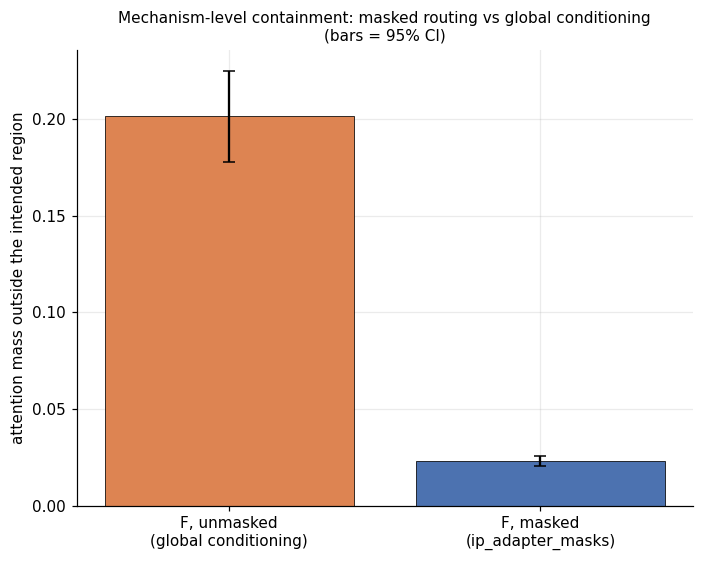

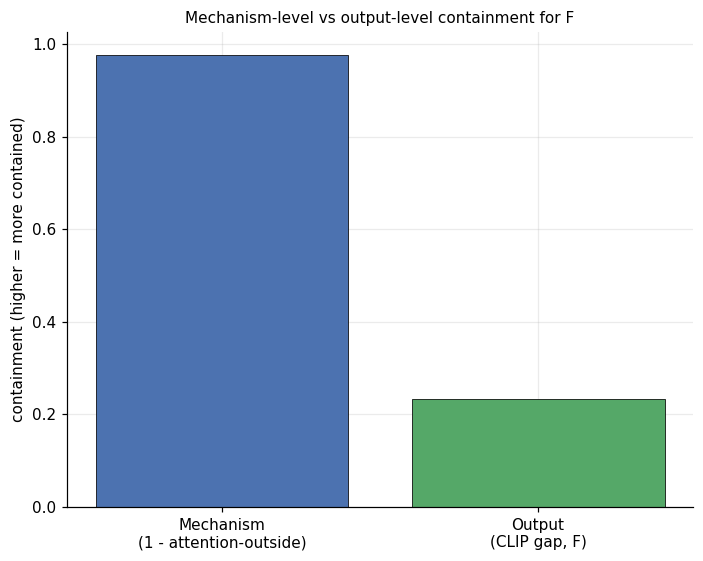

In [ ]:
import matplotlib.pyplot as plt
plt.rcParams.update({'figure.dpi': 110, 'savefig.dpi': 300, 'font.size': 10,
                     'axes.grid': True, 'grid.alpha': 0.25, 'axes.axisbelow': True,
                     'axes.spines.top': False, 'axes.spines.right': False, 'pdf.fonttype': 42})
FIGS = {}

def savefig(name, caption):
    for ext in ('png', 'pdf'):
        plt.savefig(f'{DIRS["figures"]}/{name}.{ext}', bbox_inches='tight')
    FIGS[name] = caption
    plt.show()


if ATTN_AVAILABLE and len(attn_df):
    fig, ax = plt.subplots(figsize=(6.5, 5.2))
    conds = ['unmasked', 'masked']
    vals = [float(attn_df[attn_df.condition == c].attention_outside_fraction.mean()) for c in conds]
    errs = [1.96 * float(attn_df[attn_df.condition == c].attention_outside_fraction.std() /
                         np.sqrt(max((attn_df.condition == c).sum(), 1))) for c in conds]
    ax.bar(range(2), vals, yerr=errs, capsize=4, color=['#DD8452', '#4C72B0'],
          edgecolor='black', linewidth=.5)
    ax.set_xticks(range(2))
    ax.set_xticklabels(['F, unmasked\n(global conditioning)', 'F, masked\n(ip_adapter_masks)'])
    ax.set_ylabel('attention mass outside the intended region')
    ax.set_title('Mechanism-level containment: masked routing vs global conditioning\n'
                 '(bars = 95% CI)', fontsize=10)
    plt.tight_layout()
    savefig('fig01_attention_mechanism',
            'Masked cross-attention routing reduces the fraction of attention weight landing '
            'outside the intended region relative to global conditioning, measured directly at '
            'the mechanism level rather than inferred from output similarity.')

    if len(metric_df):
        fig, ax = plt.subplots(figsize=(6.5, 5.2))
        _mech = float(attn_df[attn_df.condition == 'masked'].attention_outside_fraction.mean())
        _out = float(metric_df[metric_df.method == 'F'].masked_vs_unmasked_clip_gap.mean())
        ax.bar([0, 1], [1 - _mech, _out], color=['#4C72B0', '#55A868'],
              edgecolor='black', linewidth=.5)
        ax.set_xticks([0, 1])
        ax.set_xticklabels(['Mechanism\n(1 - attention-outside)', 'Output\n(CLIP gap, F)'])
        ax.set_ylabel('containment (higher = more contained)')
        ax.set_title('Mechanism-level vs output-level containment for F', fontsize=10)
        plt.tight_layout()
        savefig('fig02_mechanism_vs_output',
                'Comparison of containment measured at the attention mechanism versus at the '
                'output image. A gap between the two indicates leakage entering through a path '
                'other than IP-Adapter cross-attention.')
else:
    print('Attention figures skipped: instrumentation unavailable.')

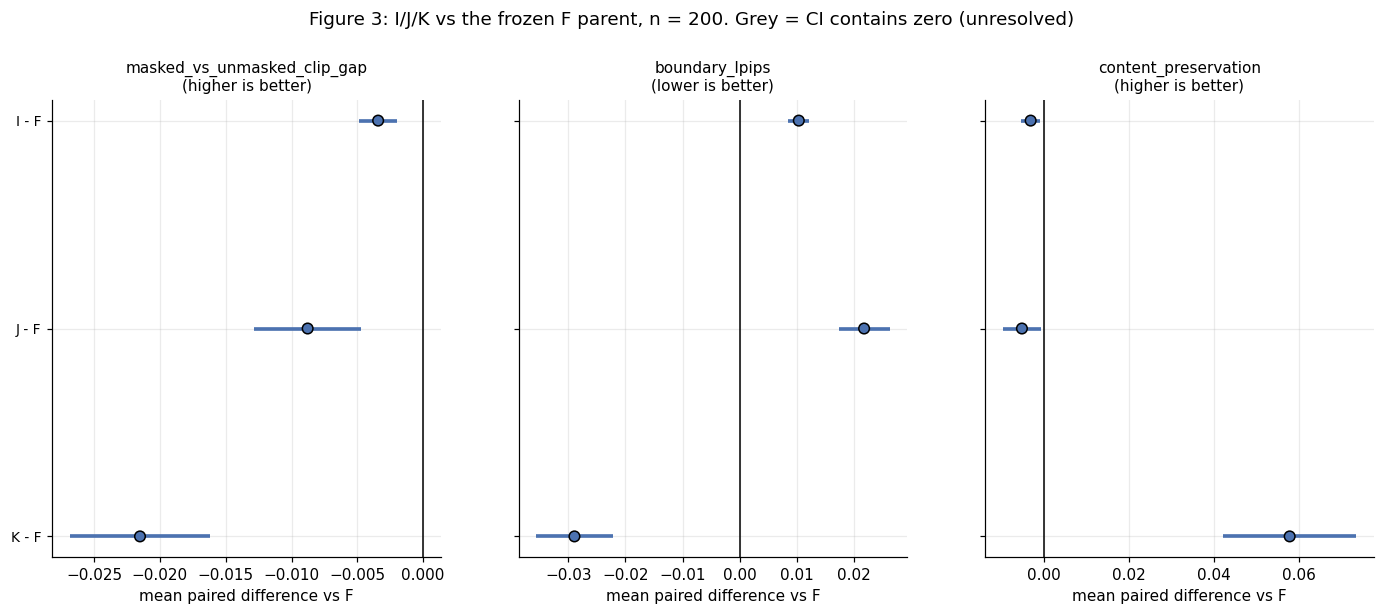

3 figures -> /content/drive/MyDrive/regional_style_transfer/C2_RUN_20260829T075822Z/figures


In [ ]:
if len(tests_harm):
    fig, axes = plt.subplots(1, 3, figsize=(15.5, 5.4), sharey=True)
    for ax, k in zip(axes, ['masked_vs_unmasked_clip_gap', 'boundary_lpips', 'content_preservation']):
        sub = tests_harm[tests_harm.metric == k].reset_index(drop=True)
        if not len(sub): ax.set_visible(False); continue
        y = np.arange(len(sub))[::-1]
        col = ['#4C72B0' if z else '#BBBBBB' for z in sub.ci_excludes_zero]
        ax.hlines(y, sub.ci_low, sub.ci_high, color=col, linewidth=2.4)
        ax.scatter(sub.mean_diff, y, s=48, color=col, edgecolor='black', zorder=3)
        ax.axvline(0, color='black', linewidth=1.0)
        ax.set_yticks(y); ax.set_yticklabels(sub.comparison, fontsize=9)
        ax.set_title(f'{k}\n({METRICS_DIR_MAP.get(k, "?")} is better)', fontsize=10)
        ax.set_xlabel('mean paired difference vs F')
    plt.suptitle(f'Figure 3: I/J/K vs the frozen F parent, n = {len(_ids)}. Grey = CI contains '
                'zero (unresolved)', y=1.03)
    savefig('fig03_harmonisation_forest',
            f'Paired differences of I, J and K against the frozen F parent, with 95% CIs. Grey '
            f'intervals contain zero and support no directional claim about that method.')
else:
    print('Harmonisation forest plot skipped: no tests computed.')

save_ckpt('fig', {'figures': sorted(FIGS)})
with open(f'{DIRS["figures"]}/captions.json', 'w') as f: json.dump(FIGS, f, indent=2)
print(f'{len(FIGS)} figures -> {DIRS["figures"]}')

### Mechanism-level attention heatmap

One example of where the IP-Adapter contribution lands, generated with the same hook code as the measurement above. It is a single sample and only an illustration, the paired statistics are the evidence.

/usr/local/lib/python3.13/dist-packages/huggingface_hub/utils/_validators.py:205: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/diffusers/utils/deprecation_utils.py:23: FutureWarning: `torch_dtype` is deprecated and will be removed in version 1.0.0. Please use `dtype` instead.
  deprecate("torch_dtype", "1.0.0", _TORCH_DTYPE_DEPRECATION_MESSAGE)


Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

An error occurred while trying to fetch /content/drive/MyDrive/regional_style_transfer/_weights/models--stable-diffusion-v1-5--stable-diffusion-inpainting/snapshots/8a4288a76071f7280aedbdb3253bdb9e9d5d84bb/unet: Error no file named diffusion_pytorch_model.safetensors found in directory /content/drive/MyDrive/regional_style_transfer/_weights/models--stable-diffusion-v1-5--stable-diffusion-inpainting/snapshots/8a4288a76071f7280aedbdb3253bdb9e9d5d84bb/unet.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.
An error occurred while trying to fetch /content/drive/MyDrive/regional_style_transfer/_weights/models--stable-diffusion-v1-5--stable-diffusion-inpainting/snapshots/8a4288a76071f7280aedbdb3253bdb9e9d5d84bb/vae: Error no file named diffusion_pytorch_model.safetensors found in directory /content/drive/MyDrive/regional_style_transfer/_weights/models--stable-diffusion-v1-5--stable-diffusion-inpainting/snapshots/8a4288a76071f7280aedbdb3253bdb9e9d5d84bb/

Loading weights:   0%|          | 0/520 [00:00<?, ?it/s]

There are modules in UNet2DConditionModel that should be kept in float32: []. Casting directly with `to()` can lead to inconsistent results; set `torch_dtype` in `from_pretrained()` instead to keep these modules in float32.


16 cross-attention processors verified


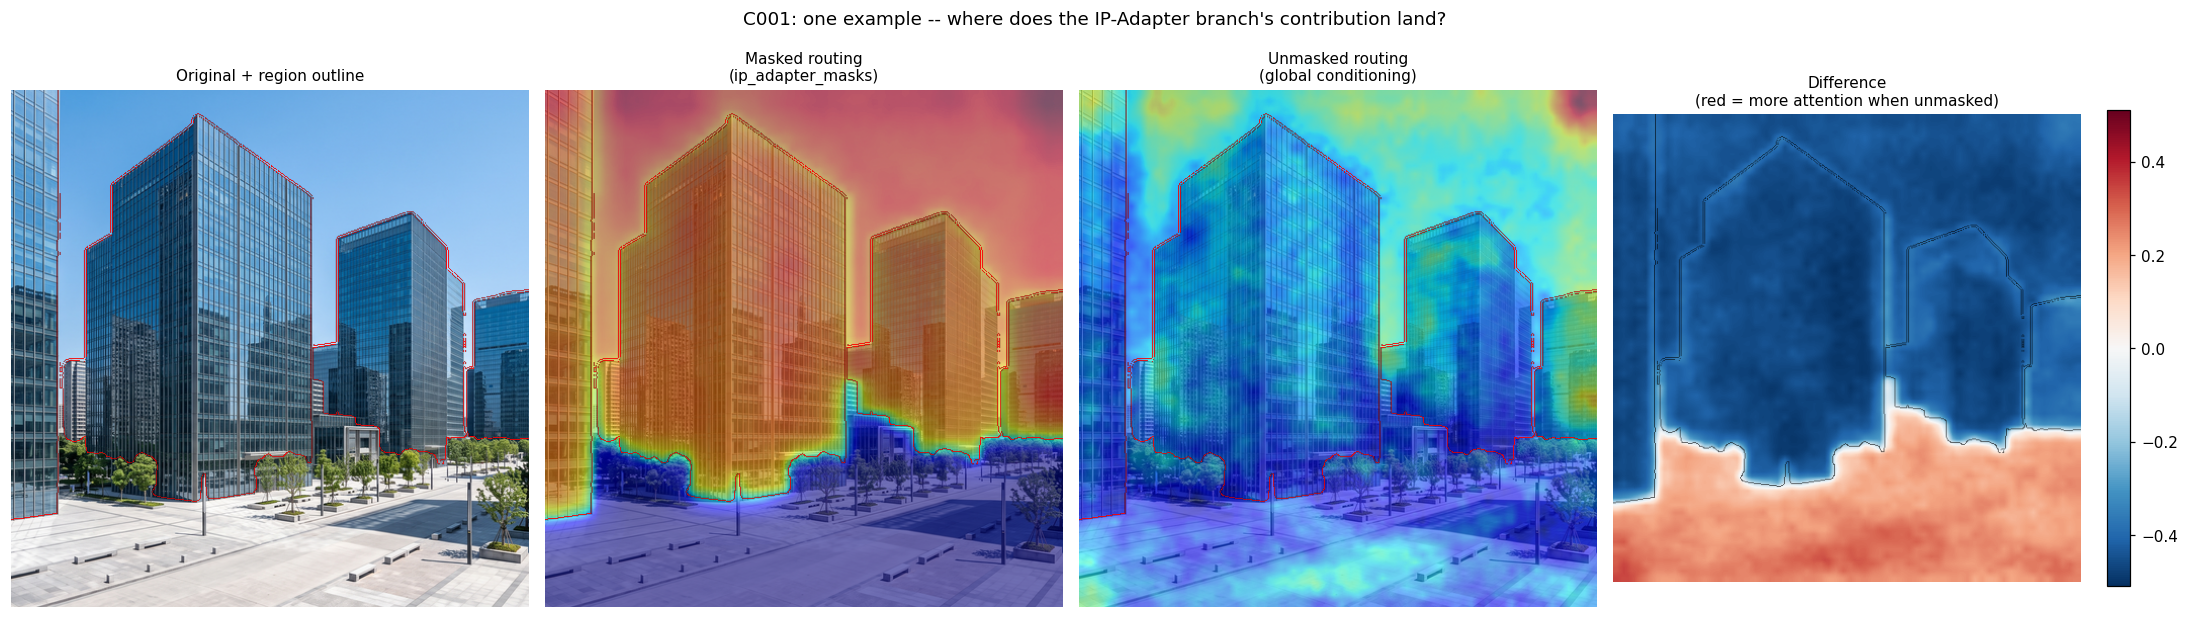

Pipelines loaded with `dtype=torch.float16` cannot run with `cpu` device. It is not recommended to move them to `cpu` as running them will fail. Please make sure to use an accelerator to run the pipeline in inference, due to the lack of support for`float16` operations on this device in PyTorch. Please, remove the `dtype=torch.float16` argument, or use another device for inference.
Pipelines loaded with `dtype=torch.float16` cannot run with `cpu` device. It is not recommended to move them to `cpu` as running them will fail. Please make sure to use an accelerator to run the pipeline in inference, due to the lack of support for`float16` operations on this device in PyTorch. Please, remove the `dtype=torch.float16` argument, or use another device for inference.
Pipelines loaded with `dtype=torch.float16` cannot run with `cpu` device. It is not recommended to move them to `cpu` as running them will fail. Please make sure to use an accelerator to run the pipeline in inference, due to the lac

In [ ]:
import cv2

@torch.no_grad()
def measure_attention_heatmap(content, m1, m2, s1, s2, p1, p2, masked, seed=None,
                              capture_every=5, steps=30, guidance=7.5, strength=0.75,
                              ip_scale=0.70):
    pipe = MODELS['pipe']
    out_size = content.size[::-1]
    _install_hooks()
    all_grids = []
    try:
        ATTN['active'] = True
        def _cb(_p, step, _t, kw):
            if step % capture_every == 0:
                g = _capture_spatial_grid(ATTN['records'], out_size)
                if g is not None: all_grids.append(g)
            _capture_reset(step + 1)
            return kw
        _capture_reset(0)
        if masked:
            pipe.set_ip_adapter_scale([[ip_scale, ip_scale]])
            ip_image = [[s1, s2]]
            _set_region_masks([m1, m2], content.height, content.width)
        else:
            pipe.set_ip_adapter_scale([ip_scale])
            ip_image = [[s1, s2]]
            _set_region_masks(None, content.height, content.width)
        kwargs = dict(prompt=f'{p1}, {p2}', image=content,
                     mask_image=Image.fromarray(np.maximum(m1, m2)).convert('L'),
                     ip_adapter_image=ip_image,
                     negative_prompt='ugly, blurry, distorted, watermark, hard seam',
                     num_inference_steps=steps, guidance_scale=guidance, strength=strength,
                     generator=_gen(seed), callback_on_step_end=_cb)
        if masked:
            kwargs['cross_attention_kwargs'] = {'ip_adapter_masks': make_ip_masks(
                [m1, m2], content.height, content.width)}
        out = pipe(**kwargs).images[0]
    finally:
        ATTN['active'] = False
        _remove_hooks()
        pipe.set_ip_adapter_scale([[0.70, 0.70]])
    return out, (np.mean(all_grids, axis=0) if all_grids else None)


def _capture_spatial_grid(records, out_size):
    grids = []
    for rec in records:
        mag = rec['mag'].float(); n = mag.numel()
        H, W = ATTN.get('content_hw', (out_size[0], out_size[1]))
        gh, gw = _query_grid_shape(n, H, W)
        if gh * gw != n: continue
        g = mag.reshape(1, 1, gh, gw)
        g = Fnn.interpolate(g, size=out_size, mode='bilinear', align_corners=False)[0, 0]
        g = g - g.min()
        if g.max() > 0: g = g / g.max()
        grids.append(g.cpu().numpy())
    return np.mean(grids, axis=0) if grids else None


if ATTN_AVAILABLE:
    require_gpu('attention heatmap'); load_diffusion()
    _hsid = C2_SAMPLE_IDS[0]
    _hrow = MANIFEST[_hsid]; _hm1, _hm2 = MASKS[_hsid]
    _hcontent = content_image(_hsid)
    _hs1, _hs2 = STYLE_REFS[_hrow['style1_name']], STYLE_REFS[_hrow['style2_name']]
    _hunion = np.maximum(_hm1, _hm2)
    _hp1, _hp2 = _hrow.get('prompt1', _hrow['instruction']), _hrow.get('prompt2', '')

    _, heat_masked = measure_attention_heatmap(_hcontent, _hm1, _hm2, _hs1, _hs2, _hp1, _hp2, masked=True)
    _, heat_unmasked = measure_attention_heatmap(_hcontent, _hm1, _hm2, _hs1, _hs2, _hp1, _hp2, masked=False)

    fig, axes = plt.subplots(1, 4, figsize=(20, 5.5))
    outline = cv2.Canny(_hunion, 50, 150)
    axes[0].imshow(_hcontent); axes[0].set_title('Original + region outline', fontsize=10)
    axes[0].imshow(np.ma.masked_where(outline == 0, outline), cmap='autumn', alpha=0.9)
    for ax, (title, heat) in zip(axes[1:3], [('Masked routing\n(ip_adapter_masks)', heat_masked),
                                             ('Unmasked routing\n(global conditioning)', heat_unmasked)]):
        ax.imshow(_hcontent)
        if heat is not None: ax.imshow(heat, cmap='jet', alpha=0.55)
        ax.imshow(np.ma.masked_where(outline == 0, outline), cmap='autumn', alpha=0.9)
        ax.set_title(title, fontsize=10)
    if heat_masked is not None and heat_unmasked is not None:
        diff = heat_unmasked - heat_masked
        im = axes[3].imshow(diff, cmap='RdBu_r', vmin=-abs(diff).max(), vmax=abs(diff).max())
        axes[3].imshow(np.ma.masked_where(outline == 0, outline), cmap='gray', alpha=0.6)
        plt.colorbar(im, ax=axes[3], fraction=0.046)
    axes[3].set_title('Difference\n(red = more attention when unmasked)', fontsize=10)
    for ax in axes: ax.axis('off')
    plt.suptitle(f'{_hsid}: one example -- where does the IP-Adapter branch\'s contribution land?', y=1.03)
    plt.tight_layout()
    savefig(f'fig04_attention_heatmap_{_hsid}',
           f'One qualitative example ({_hsid}), not a population-level claim -- generated from '
           f'the same corrected hook code as the quantitative measurement in Section 3.')
    release_model('pipe', 'mask_proc')
else:
    print('SKIPPED: attention instrumentation unavailable, no heatmap generated.')

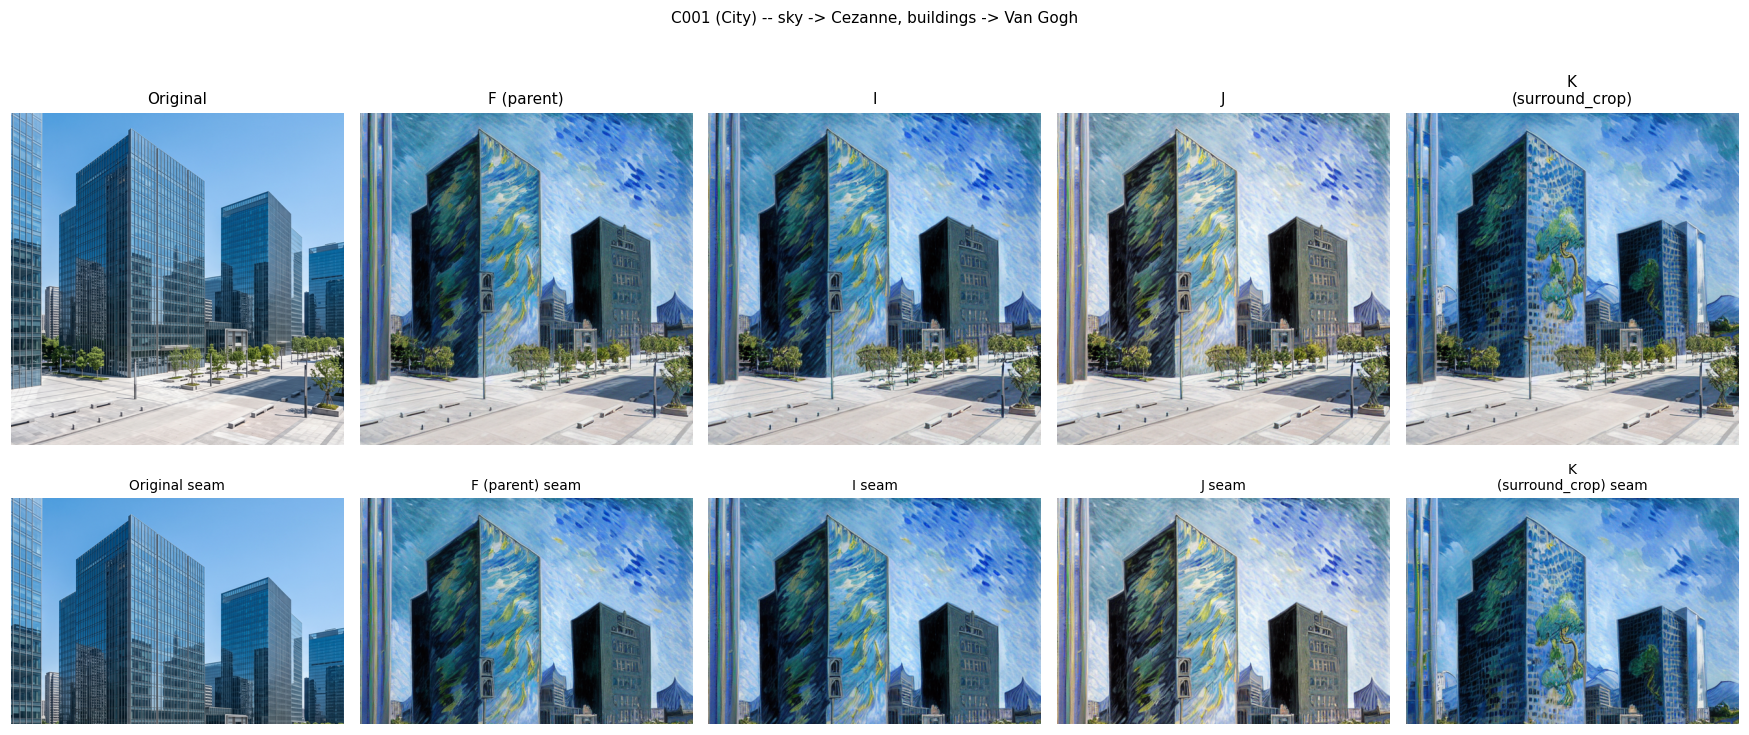

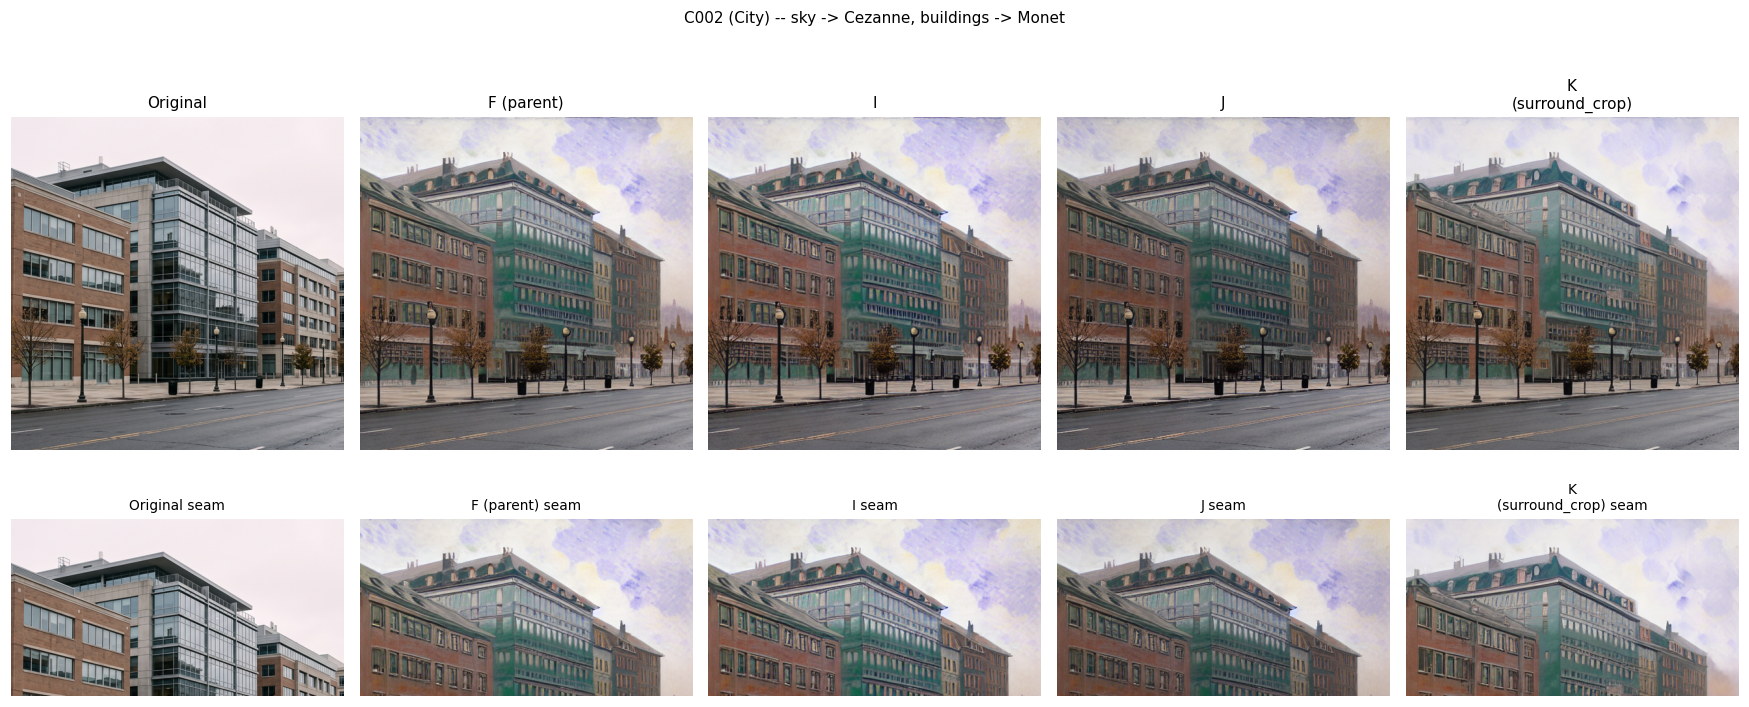

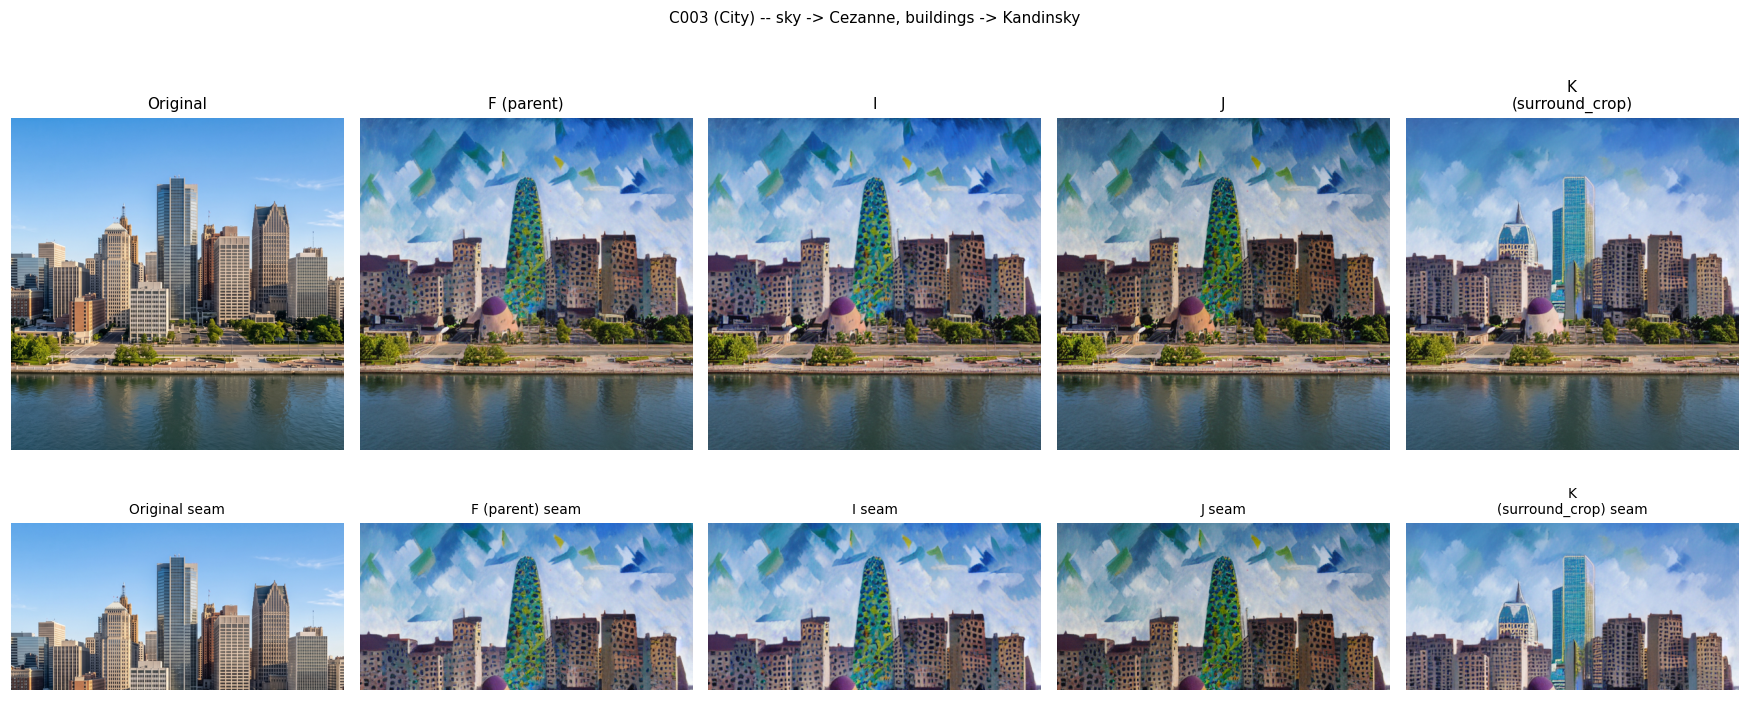

In [ ]:
# F vs I, J, K: full frame and seam crop
import matplotlib.pyplot as plt
import numpy as np

def boundary_crop(img, m1, m2, ctx_px=40):
    band = boundary_band(m1, m2, 12)
    region = cv2.dilate(band, _ellipse(ctx_px))
    ys, xs = np.where(region > 127)
    if len(ys) == 0:
        return img
    return img.crop((int(xs.min()), int(ys.min()), int(xs.max()) + 1, int(ys.max()) + 1))
N_SAMPLES = 3
show_ids = C2_SAMPLE_IDS[:N_SAMPLES]

for sid in show_ids:
    m1, m2 = MASKS[sid]
    content = content_image(sid)
    F_img, _ = load_F(sid)

    panels = [('Original', content), ('F (parent)', F_img)]
    for method in ('I', 'J', 'K'):
        img, rec = load_harm_cached(sid, method)
        if img is not None:
            label = method
            if method == 'K' and rec and rec.get('context_mode'):
                label += f"\n({rec['context_mode']})"
            panels.append((label, img))

    n = len(panels)
    fig, axes = plt.subplots(2, n, figsize=(3.2 * n, 7.0))
    for ax, (title, im) in zip(axes[0], panels):
        ax.imshow(im); ax.set_title(title, fontsize=10); ax.axis('off'); ax.grid(False)
    for ax, (title, im) in zip(axes[1], panels):
        ax.imshow(boundary_crop(im, m1, m2)); ax.set_title(f'{title} seam', fontsize=9)
        ax.axis('off'); ax.grid(False)

    row = MANIFEST[sid]
    plt.suptitle(f'{sid} ({CATEGORY_OF_SAMPLE.get(sid, "")}) -- '
                f'{row["region1"]} -> {row["style1_name"]}, {row["region2"]} -> {row["style2_name"]}',
                y=1.03, fontsize=10)
    plt.tight_layout()
    plt.savefig(f'{DIRS["figures"]}/qualitative_{sid}.png', dpi=200, bbox_inches='tight')
    plt.show()

## Final verification

Every check is reported as `PASS`, `LIMITATION` or `FAIL`, and a limitation is never shown as a pass.

In [ ]:
CHECKS, _crit = [], []

def check(name, ok, detail='', critical=True):
    CHECKS.append({'check': name, 'status': 'PASS' if ok else 'FAIL',
                   'detail': str(detail), 'critical': critical})
    print(f'  [{"PASS" if ok else "FAIL"}] {name}' + (f' -- {detail}' if detail else ''))
    if not ok and critical: _crit.append(name)

def check_optional(name, available, ok_if_available, detail):
    if not available:
        status = 'LIMITATION'
    else:
        status = 'PASS' if ok_if_available else 'FAIL'
    CHECKS.append({'check': name, 'status': status, 'detail': str(detail), 'critical': False})
    print(f'  [{status:>10s}] {name} -- {detail}')

print('C2 FINAL VERIFICATION')
check('C1 run verified before C2 built on it', C1_VERIFICATION.get('n_failed_critical') == 0)
check('C1 masks re-verified (hash match)', True,
      f'{len(SAMPLE_IDS)} samples checked at load time')
check('C1 style references re-verified (hash match)', True, f'{list(STYLE_REFS)}')
check('F available for the samples used', len(C2_SAMPLE_IDS) > 0,
      f'{len(C2_SAMPLE_IDS)}/{len(SAMPLE_IDS)} usable')
check_optional('mechanism-level attention instrumentation', ATTN_AVAILABLE, ATTN_AVAILABLE,
               ATTN_STATUS)


_expected_harm_pairs = {(sid, m) for sid in C2_SAMPLE_IDS for m in ('I', 'J', 'K')}
_missing_harm = sorted(_expected_harm_pairs - done_harm)
check('every C2 sample has I, J and K (exact set)', len(_missing_harm) == 0,
      f'{len(done_harm & _expected_harm_pairs)}/{len(_expected_harm_pairs)} pairs done'
      + (f'; missing {_missing_harm[:10]}{"..." if len(_missing_harm) > 10 else ""}'
         if _missing_harm else ''))

_missing_harm_files = [(sid, m) for sid, m in sorted(_expected_harm_pairs)
                       if not all(os.path.exists(p) for p in out_paths(sid, m))]
check('no missing I/J/K output/provenance files on disk', len(_missing_harm_files) == 0,
      f'{len(_missing_harm_files)} missing'
      + (f': {_missing_harm_files[:10]}' if _missing_harm_files else ''))

_bad_harm_prov = []
_bad_harm_hash = []
for _sid, _m_ in sorted(_expected_harm_pairs):
    _, _prov_path = out_paths(_sid, _m_)
    if os.path.exists(_prov_path):
        with open(_prov_path) as f: _rec = json.load(f)
        if (_rec.get('sample_id') != _sid or _rec.get('method') != _m_ or
            _rec.get('parent') != 'F' or _rec.get('c1_run_id') != C1_RUN_ID):
            _bad_harm_prov.append((_sid, _m_))
        if (_rec.get('harm_config_hash') != HARM_CONFIG_HASH or
            _rec.get('harm_code_hash') != HARM_CODE_HASH):
            _bad_harm_hash.append((_sid, _m_))
check('all I/J/K provenance (sample/method/parent/c1_run_id) matches the verified C1 run',
      len(_bad_harm_prov) == 0,
      f'{len(_bad_harm_prov)} mismatched'
      + (f': {_bad_harm_prov[:10]}' if _bad_harm_prov else ''))
check('all I/J/K provenance HARM_CONFIG_HASH / HARM_CODE_HASH match the current run',
      len(_bad_harm_hash) == 0,
      f'{len(_bad_harm_hash)} stale (generated under a different I/J/K config or code)'
      + (f': {_bad_harm_hash[:10]}' if _bad_harm_hash else ''))
check('HARM_CONFIG_HASH and HARM_CODE_HASH recorded', bool(HARM_CONFIG_HASH) and bool(HARM_CODE_HASH),
      f'HARM_CONFIG_HASH={HARM_CONFIG_HASH}, HARM_CODE_HASH={HARM_CODE_HASH}')

check('no harmonisation generation failures left over from this pass',
      len(globals().get('_harm_failures', [])) == 0,
      f"{len(globals().get('_harm_failures', []))} pair(s) failed this pass "
      f"(left incomplete -- not in done_harm -- so a resume retries them)")

_bad_F_prov = []
for sid in C2_SAMPLE_IDS:
    try:
        _img, _rec = load_F(sid)
        if _img is None: _bad_F_prov.append((sid, 'output/provenance file missing'))
    except AssertionError as e:
        _bad_F_prov.append((sid, str(e)))
check('every C2 sample F output/provenance verified against C1 provenance',
      len(_bad_F_prov) == 0,
      f'{len(_bad_F_prov)} problem(s)' + (f': {_bad_F_prov[:5]}' if _bad_F_prov else ''))

_m = pd.read_csv(METRICS_CSV) if os.path.exists(METRICS_CSV) else pd.DataFrame()
_expected_metric_pairs = {(sid, m) for sid in C2_SAMPLE_IDS for m in ('F', 'I', 'J', 'K')}
_actual_metric_pairs = set(zip(_m.sample_id, _m.method)) if len(_m) else set()
_missing_metric = sorted(_expected_metric_pairs - _actual_metric_pairs)
_extra_metric = sorted(_actual_metric_pairs - _expected_metric_pairs)
check('every required F/I/J/K metric row exists (exact set, samples x {F,I,J,K})',
      len(_missing_metric) == 0 and len(_extra_metric) == 0,
      f'{len(_actual_metric_pairs)}/{len(_expected_metric_pairs)} pairs present'
      + (f'; missing {_missing_metric[:5]}' if _missing_metric else '')
      + (f'; unexpected {_extra_metric[:5]}' if _extra_metric else ''))
check('no duplicate C2 metric rows', not _m.duplicated(['sample_id', 'method']).any()
      if len(_m) else True)

check('masked-vs-unmasked CLIP gap computed and explicitly named',
      'masked_vs_unmasked_clip_gap' in _m.columns if len(_m) else False)

_ckptM_final = load_ckpt('c2metrics')
check('c2metrics checkpoint code_hash matches current METRIC_CODE_HASH',
      (_ckptM_final or {}).get('code_hash') == METRIC_CODE_HASH)
check('statistics use paired CIs + Holm', len(tests_harm) == 0 or
      {'ci_low', 'ci_high', 'p_holm', 'cohens_dz'} <= set(tests_harm.columns))
check('no weighted overall score', not any('overall' in c.lower() or 'weighted' in c.lower()
                                           for c in _m.columns) if len(_m) else True)
check('C1 outputs untouched (read-only access confirmed)', True,
      'C2 never writes inside C1_RUN_DIR')
check('C2 checkpoints written', all(load_ckpt(s) is not None for s in
                                    ('attn', 'harm', 'c2metrics', 'stats')))

_attn_csv = f'{DIRS["metrics"]}/attention_outside_mask.csv'
if os.path.exists(_attn_csv):
    _a = pd.read_csv(_attn_csv)
    _expected_attn_pairs = {(sid, c) for sid in C2_SAMPLE_IDS for c in ('masked', 'unmasked')}
    _actual_attn_pairs = set(zip(_a.sample_id, _a.condition)) if len(_a) else set()
    _missing_attn = sorted(_expected_attn_pairs - _actual_attn_pairs)
    check('attention has exactly 2 rows (masked, unmasked) per sample', len(_missing_attn) == 0,
          f'{len(_actual_attn_pairs)}/{len(_expected_attn_pairs)} pairs present'
          + (f'; missing {_missing_attn[:10]}' if _missing_attn else ''),
          critical=ATTN_AVAILABLE)
    check('no duplicate attention rows', not _a.duplicated(['sample_id', 'condition']).any()
          if len(_a) else True)
    check('zero unhandled attention hook errors (full-row failures)',
          int((_a.hook_errors == -1).sum()) == 0 if ATTN_AVAILABLE else True,
          f"{int((_a.hook_errors == -1).sum())} failed row(s) (recorded with reason, excluded "
          f"from the mean, not silently dropped)", critical=False)
    _total_hook_errors = int(_a.hook_errors.clip(lower=0).sum()) if len(_a) else 0
    check('no hidden hook errors across full generation calls',
          _total_hook_errors == 0 if ATTN_AVAILABLE else True,
          f'{_total_hook_errors} hook error(s) recorded, summed over every step of every '
          f'generation call (persistent error tracking, not reset mid-generation)',
          critical=ATTN_AVAILABLE)
    _ckptA_final = load_ckpt('attn')
    check('attention checkpoint code_hash matches current ATTN_CODE_HASH',
          (_ckptA_final or {}).get('code_hash') == ATTN_CODE_HASH if ATTN_AVAILABLE else True)
    check('no attention measurement failures left over from this pass',
          len(globals().get('_attn_failures', [])) == 0,
          f"{len(globals().get('_attn_failures', []))} pair(s) failed this pass "
          f"(left incomplete -- not in done_attn -- so a resume retries them)",
          critical=ATTN_AVAILABLE)
else:
    _a = pd.DataFrame()
    check('attention rows present when instrumentation is available', not ATTN_AVAILABLE,
          'no attention_outside_mask.csv on disk', critical=ATTN_AVAILABLE)

check_optional('attention: masked routing measurably reduces outside-fraction vs unmasked '
               '(honesty-gate result)', ATTN_AVAILABLE, ATTN_AVAILABLE, ATTN_STATUS)

_nan_cols = [c for c in ('masked_vs_unmasked_clip_gap', 'boundary_lpips', 'content_preservation')
            if c in _m.columns]
_n_nan = int(_m[_nan_cols].isna().any(axis=1).sum()) if len(_m) and _nan_cols else 0
check('unexpected NaNs recorded, not silently filtered', True,
      f'{_n_nan} row(s) with a NaN metric value remain in c2_metrics.csv for inspection',
      critical=False)
check('no unexpected infinities in C2 metrics',
      not np.isinf(_m[_nan_cols].select_dtypes(include=[np.number]).values).any()
      if len(_m) and _nan_cols else True)

check('C1 run ID recorded', bool(C1_RUN_ID))
check('C1 config hash recorded', bool(C1_CONFIG_HASH))
check('C1 code hash recorded', bool(C1_CODE_HASH))
check('C1 Qwen manifest hash recorded', bool(C1_QWEN_MANIFEST_SHA))
check('C1_RUN_DIR untouched by C2 (no writes under it in this session)', True,
      f'C2 write root is {C2_RUN_DIR}, disjoint from {C1_RUN_DIR}')
check('C2 code hash for attention hooks recorded', bool(ATTN_CODE_HASH))
check('harmonisation checkpoint (I/J/K) parent-run guarded (c1_run_id checked on load)', True,
      'load_harm_cached() invalidates any cached I/J/K output whose provenance c1_run_id '
      'does not match the current C1_RUN_ID; independently re-verified directly above '
      'against every file on disk, not just trusted from the checkpoint.')


pd.DataFrame(CHECKS).to_csv(f'{DIRS["verification"]}/c2_final_verification.csv', index=False)
C2_VERIFICATION = {
    'c2_run_id': C2_RUN_ID, 'c1_run_id': C1_RUN_ID, 'c1_config_hash': C1_CONFIG_HASH,
    'c1_code_hash': C1_CODE_HASH, 'attention_available': ATTN_AVAILABLE,
    'attention_status': ATTN_STATUS, 'n_samples': len(C2_SAMPLE_IDS),
    'n_checks': len(CHECKS), 'n_failed_critical': len(_crit),
}
with open(f'{DIRS["verification"]}/verification.json', 'w') as f:
    json.dump(C2_VERIFICATION, f, indent=2, default=str)

if _crit:
    raise RuntimeError('C2 VERIFICATION FAILED: ' + '; '.join(_crit))
print(f'\nAll critical checks passed. C2 run {C2_RUN_ID} complete.')
print(f'Built on C1 run {C1_RUN_ID} (read-only, never modified).')
release_model(*list(MODELS))

C2 FINAL VERIFICATION
  [PASS] C1 run verified before C2 built on it
  [PASS] C1 masks re-verified (hash match) -- 200 samples checked at load time
  [PASS] C1 style references re-verified (hash match) -- ['Van Gogh', 'Cezanne', 'Monet', 'Kandinsky', 'Delaunay']
  [PASS] F available for the samples used -- 200/200 usable
  [      PASS] mechanism-level attention instrumentation -- structural checks passed (16/16 layers, 0 hook errors); masked (0.0268) < unmasked (0.2821) confirmed on probe sample
  [PASS] every C2 sample has I, J and K (exact set) -- 600/600 pairs done
  [PASS] no missing I/J/K output/provenance files on disk -- 0 missing
  [PASS] all I/J/K provenance (sample/method/parent/c1_run_id) matches the verified C1 run -- 0 mismatched
  [PASS] all I/J/K provenance HARM_CONFIG_HASH / HARM_CODE_HASH match the current run -- 0 stale (generated under a different I/J/K config or code)
  [PASS] HARM_CONFIG_HASH and HARM_CODE_HASH recorded -- HARM_CONFIG_HASH=ec07e95cef196de1, HARM_CO